## Evaluate results across all datasets

In [1]:
# imports + paths
from pathlib import Path
import pandas as pd

BASE = Path("/data/shared/fsibilla/clean_code/Q1")
EXP_BASE = BASE / "experiments_sectoronly"
OUT_DIR = BASE / "across_experiments_eval_sectoronly"
OUT_DIR.mkdir(parents=True, exist_ok=True)

experiments = [
    ("lka", "micron", '1'),
    ("nga", "micron", '1'),
    ("eth", "micron", '1'),
    ("lka", "vam", '1'),
    ("moz", "vam", '1'),
    ("yem", "mvam", '10'),
    ("nga", "mics", '1'),
    ("zwe", "mics", '1'),
]

In [2]:
# read + tag + collect
dfs = []
geom_dfs = []

for country, dataset, train_int in experiments:
    exp_id = f"{country}_{dataset}"
    fp = EXP_BASE / exp_id / "results" / "evaluation" / f"eval_adm1_seed_metrics_train_{train_int}.csv"
    df = pd.read_csv(fp)

    df["country"] = country
    df["dataset"] = dataset
    df["train_percent_int"] = train_int
    df["experiment_id"] = exp_id

    # geometry lookup (one geom per exp+adm1)
    g = (
        df[["experiment_id", "country", "dataset", "train_percent_int", "adm1_code", "adm1_name", "adm1geometry"]]
        .dropna(subset=["adm1geometry"])
        .drop_duplicates(subset=["experiment_id", "adm1_code"], keep="first")
        .reset_index(drop=True)
    )
    geom_dfs.append(g)

    # metrics without geometry
    df = df.drop(columns=["adm1geometry"], errors="ignore")
    dfs.append(df)

metrics_all = pd.concat(dfs, ignore_index=True)
geom_lookup = pd.concat(geom_dfs, ignore_index=True)

metrics_all.shape, geom_lookup.shape

((3575, 19), (146, 7))

In [3]:
# quick sanity checks
print("experiments in metrics:", metrics_all["experiment_id"].nunique())
print("experiments in geom:", geom_lookup["experiment_id"].nunique())
print("missing adm1_code in metrics:", metrics_all["adm1_code"].isna().sum())
print("duplicate geom keys (exp+adm1_code):", geom_lookup.duplicated(["experiment_id", "adm1_code"]).sum())

experiments in metrics: 8
experiments in geom: 8
missing adm1_code in metrics: 0
duplicate geom keys (exp+adm1_code): 0


In [4]:
# save (csv + parquet)
metrics_csv = OUT_DIR / "metrics_all_experiments_sectoronly.csv"
geom_csv = OUT_DIR / "adm1_geometry_lookup.csv"

metrics_all.to_csv(metrics_csv, index=False)
geom_lookup.to_csv(geom_csv, index=False)

# parquet is nicer for speed/size
metrics_parquet = OUT_DIR / "metrics_all_experiments.parquet"
geom_parquet = OUT_DIR / "adm1_geometry_lookup.parquet"

metrics_all.to_parquet(metrics_parquet, index=False)
geom_lookup.to_parquet(geom_parquet, index=False)

metrics_csv, geom_csv

(PosixPath('/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/metrics_all_experiments_sectoronly.csv'),
 PosixPath('/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/adm1_geometry_lookup.csv'))

## Plot points individually for each adm1 and variable for all experiments. error bars are from 5 seeds

In [5]:
# seed aggregation (per exp-adm1-target): mean + SE over seeds
import numpy as np
import pandas as pd

cols_needed = [
    "experiment_id","country","dataset","train_percent_int",
    "seed","adm1_code","adm1_name","target",
    "emd_gen","emd_nat","emd_over",
    "absmeanerr_gen","absmeanerr_nat","absmeanerr_over",
]
df = metrics_all[cols_needed].copy()

group_keys = ["experiment_id","country","dataset","train_percent_int","adm1_code","adm1_name","target"]

adm1_seed_agg = (
    df.groupby(group_keys, as_index=False)
      .agg(
          n_seeds=("seed","nunique"),

          emd_gen_mean=("emd_gen","mean"),
          emd_gen_sd=("emd_gen","std"),
          emd_nat_mean=("emd_nat","mean"),
          emd_nat_sd=("emd_nat","std"),
          emd_over_mean=("emd_over","mean"),
          emd_over_sd=("emd_over","std"),

          abs_gen_mean=("absmeanerr_gen","mean"),
          abs_gen_sd=("absmeanerr_gen","std"),
          abs_nat_mean=("absmeanerr_nat","mean"),
          abs_nat_sd=("absmeanerr_nat","std"),
          abs_over_mean=("absmeanerr_over","mean"),
          abs_over_sd=("absmeanerr_over","std"),
      )
)

# SD NaN if n_seeds==1
for c in [c for c in adm1_seed_agg.columns if c.endswith("_sd")]:
    adm1_seed_agg[c] = adm1_seed_agg[c].fillna(0.0)

# SE over seeds
for m in ["emd_gen","emd_nat","emd_over","abs_gen","abs_nat","abs_over"]:
    adm1_seed_agg[f"{m}_se"] = adm1_seed_agg[f"{m}_sd"] / np.sqrt(adm1_seed_agg["n_seeds"].clip(lower=1))

adm1_seed_agg.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,n_seeds,emd_gen_mean,emd_gen_sd,...,abs_nat_mean,abs_nat_sd,abs_over_mean,abs_over_sd,emd_gen_se,emd_nat_se,emd_over_se,abs_gen_se,abs_nat_se,abs_over_se
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,5,0.184123,0.081117,...,2.127490,0.722712,0.681358,0.494599,0.036277,0.210148,0.085937,0.119956,0.323207,0.221191
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,5,0.346497,0.287425,...,0.292243,0.242414,1.203997,0.961886,0.128540,0.014919,0.128242,0.358920,0.108411,0.430168
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,5,0.522871,0.377565,...,0.642937,0.394849,1.398538,0.540387,0.168852,0.080351,0.175408,0.312474,0.176582,0.241669
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,5,0.234002,0.117222,...,2.470215,0.729274,0.556471,0.462169,0.052423,0.126673,0.067391,0.161907,0.326141,0.206688
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,5,0.722027,0.543692,...,0.816005,0.487976,1.319158,0.463974,0.243147,0.270022,0.263485,0.167399,0.218230,0.207495


In [6]:
# (optional) keep only what you need for plotting at adm1 level
adm1_seed_plot = adm1_seed_agg[[
    "experiment_id","country","dataset","train_percent_int",
    "adm1_code","adm1_name","target","n_seeds",
    "emd_gen_mean","emd_gen_se","emd_nat_mean","emd_nat_se","emd_over_mean","emd_over_se",
    "abs_gen_mean","abs_gen_se","abs_nat_mean","abs_nat_se","abs_over_mean","abs_over_se",
]].copy()

adm1_seed_plot.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,n_seeds,emd_gen_mean,emd_gen_se,emd_nat_mean,emd_nat_se,emd_over_mean,emd_over_se,abs_gen_mean,abs_gen_se,abs_nat_mean,abs_nat_se,abs_over_mean,abs_over_se
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,5,0.184123,0.036277,0.774883,0.210148,0.354541,0.085937,0.281076,0.119956,2.127490,0.323207,0.681358,0.221191
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,5,0.346497,0.128540,0.230833,0.014919,0.579000,0.128242,0.666400,0.358920,0.292243,0.108411,1.203997,0.430168
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,5,0.522871,0.168852,0.308993,0.080351,0.669080,0.175408,0.983125,0.312474,0.642937,0.176582,1.398538,0.241669
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,5,0.234002,0.052423,0.825422,0.126673,0.263051,0.067391,0.456924,0.161907,2.470215,0.326141,0.556471,0.206688
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,5,0.722027,0.243147,0.575250,0.270022,0.831135,0.263485,1.131230,0.167399,0.816005,0.218230,1.319158,0.207495


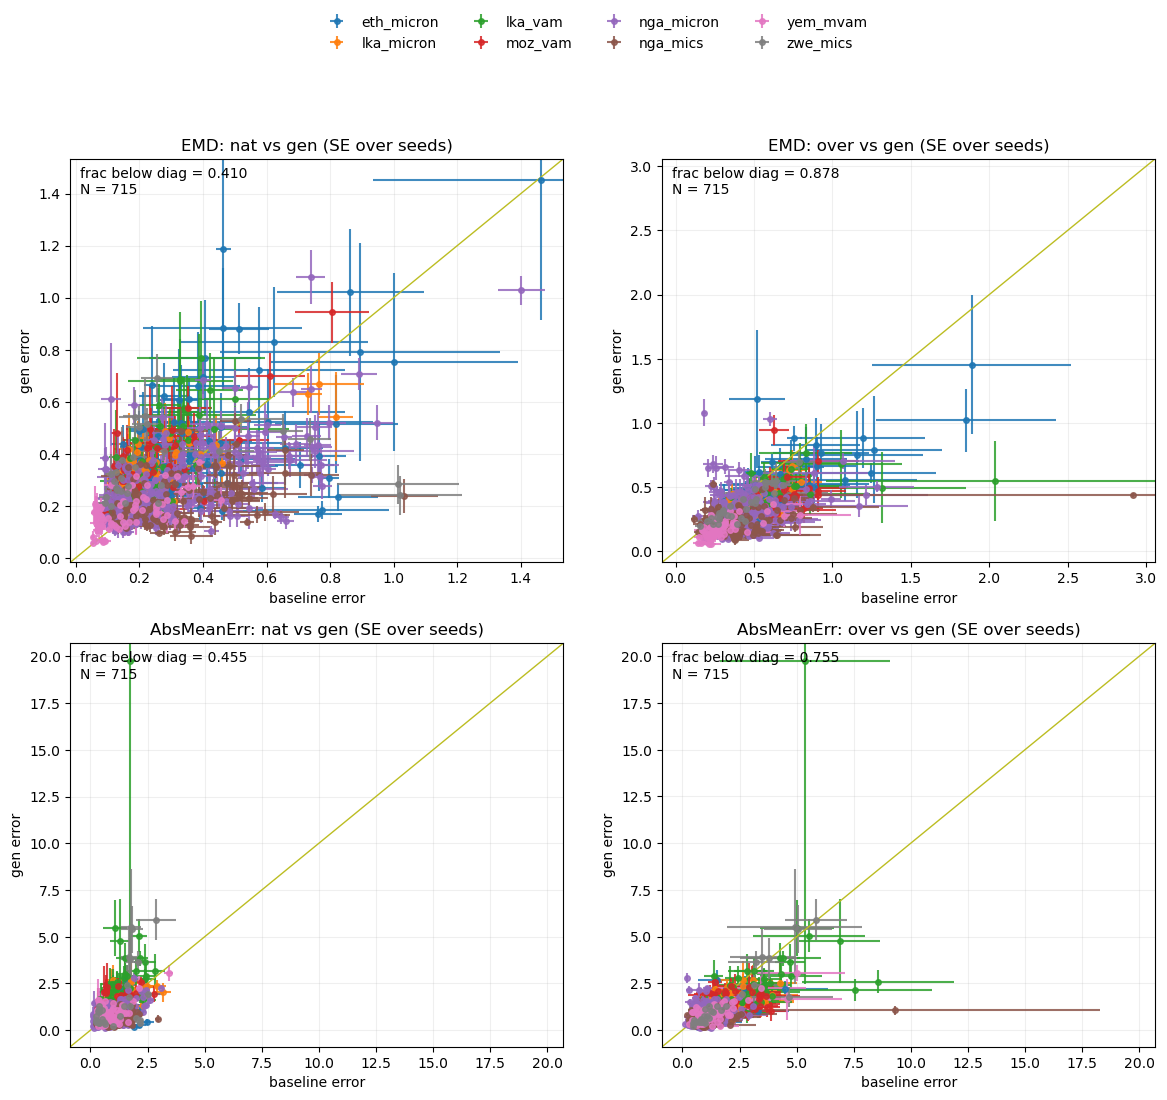

In [7]:
# plot: per-adm1-variable points, error bars = SE over seeds
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("emd_nat_mean",  "emd_nat_se",  "emd_gen_mean",  "emd_gen_se",  "EMD: nat vs gen (SE over seeds)"),
    ("emd_over_mean", "emd_over_se", "emd_gen_mean",  "emd_gen_se",  "EMD: over vs gen (SE over seeds)"),
    ("abs_nat_mean",  "abs_nat_se",  "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: nat vs gen (SE over seeds)"),
    ("abs_over_mean", "abs_over_se", "abs_gen_mean",  "abs_gen_se",  "AbsMeanErr: over vs gen (SE over seeds)"),
]

df_plot = adm1_seed_plot.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(df_plot["experiment_id"].unique())

for ax, (xmean, xse, ymean, yse, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = df_plot[df_plot["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none", alpha=0.85, markersize=4,
            label=exp_id
        )

    # diagonal + bounds + fraction below
    x = df_plot[xmean].to_numpy()
    y = df_plot[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.85)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

## aggregate across adm1 as well

In [8]:
# seed aggregation: just average over seeds (no seed uncertainty kept)
import numpy as np
import pandas as pd

cols_needed = [
    "experiment_id","country","dataset","train_percent_int",
    "seed","adm1_code","adm1_name","target",
    "emd_gen","emd_nat","emd_over",
    "absmeanerr_gen","absmeanerr_nat","absmeanerr_over",
]
df = metrics_all[cols_needed].copy()

group_keys = ["experiment_id","country","dataset","train_percent_int","adm1_code","adm1_name","target"]

adm1_seedmean = (
    df.groupby(group_keys, as_index=False)
      .agg(
          emd_gen_mean=("emd_gen","mean"),
          emd_nat_mean=("emd_nat","mean"),
          emd_over_mean=("emd_over","mean"),
          abs_gen_mean=("absmeanerr_gen","mean"),
          abs_nat_mean=("absmeanerr_nat","mean"),
          abs_over_mean=("absmeanerr_over","mean"),
      )
)

adm1_seedmean.head()

,experiment_id,country,dataset,train_percent_int,adm1_code,adm1_name,target,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean
0,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,avg_adult_education,0.184123,0.774883,0.354541,0.281076,2.127490,0.681358
1,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fe_ai,0.346497,0.230833,0.579000,0.666400,0.292243,1.203997
2,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,fol_ai,0.522871,0.308993,0.669080,0.983125,0.642937,1.398538
3,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,log_exp,0.234002,0.825422,0.263051,0.456924,2.470215,0.556471
4,eth_micron,eth,micron,1,Addis Ababa,Addis Ababa,va_ai,0.722027,0.575250,0.831135,1.131230,0.816005,1.319158


In [9]:
import numpy as np
import pandas as pd

keys_var = ["experiment_id","country","dataset","train_percent_int","target"]

def _sd_over_adm1(x: pd.Series) -> float:
    n = x.shape[0]
    if n <= 1:
        return 0.0
    return float(x.std(ddof=1))  # sample SD

var_exp = (
    adm1_seedmean.groupby(keys_var, as_index=False)
    .agg(
        n_adm1=("adm1_code","nunique"),

        emd_gen_mean=("emd_gen_mean","mean"),
        emd_nat_mean=("emd_nat_mean","mean"),
        emd_over_mean=("emd_over_mean","mean"),

        abs_gen_mean=("abs_gen_mean","mean"),
        abs_nat_mean=("abs_nat_mean","mean"),
        abs_over_mean=("abs_over_mean","mean"),

        emd_gen_sd=("emd_gen_mean", _sd_over_adm1),
        emd_nat_sd=("emd_nat_mean", _sd_over_adm1),
        emd_over_sd=("emd_over_mean", _sd_over_adm1),

        abs_gen_sd=("abs_gen_mean", _sd_over_adm1),
        abs_nat_sd=("abs_nat_mean", _sd_over_adm1),
        abs_over_sd=("abs_over_mean", _sd_over_adm1),
    )
)

var_exp.head()

,experiment_id,country,dataset,train_percent_int,target,n_adm1,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean,emd_gen_sd,emd_nat_sd,emd_over_sd,abs_gen_sd,abs_nat_sd,abs_over_sd
0,eth_micron,eth,micron,1,avg_adult_education,11,0.325904,0.341745,0.458787,0.686541,0.968984,1.326388,0.096006,0.182390,0.124264,0.272299,0.493875,0.423894
1,eth_micron,eth,micron,1,fe_ai,11,0.390958,0.367028,0.513749,0.854727,0.857837,1.061332,0.176945,0.217723,0.127456,0.469870,0.600894,0.358328
2,eth_micron,eth,micron,1,fol_ai,11,0.449282,0.467211,0.643172,0.905264,0.987986,1.342527,0.229690,0.232712,0.428410,0.534315,0.487059,1.076475
3,eth_micron,eth,micron,1,log_exp,11,0.326498,0.348894,0.494241,0.791942,0.974722,1.248337,0.141660,0.173999,0.174796,0.363053,0.537849,0.518041
4,eth_micron,eth,micron,1,va_ai,11,0.642691,0.610436,0.821649,0.951564,0.982126,1.297925,0.332878,0.335579,0.435274,0.581988,0.559903,0.672878


In [10]:
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np

cmap = plt.get_cmap('Set2')
n_colors = 8  # quante linee vuoi distinguere
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

plt.rcParams['axes.prop_cycle'] = cycler('color', colors)

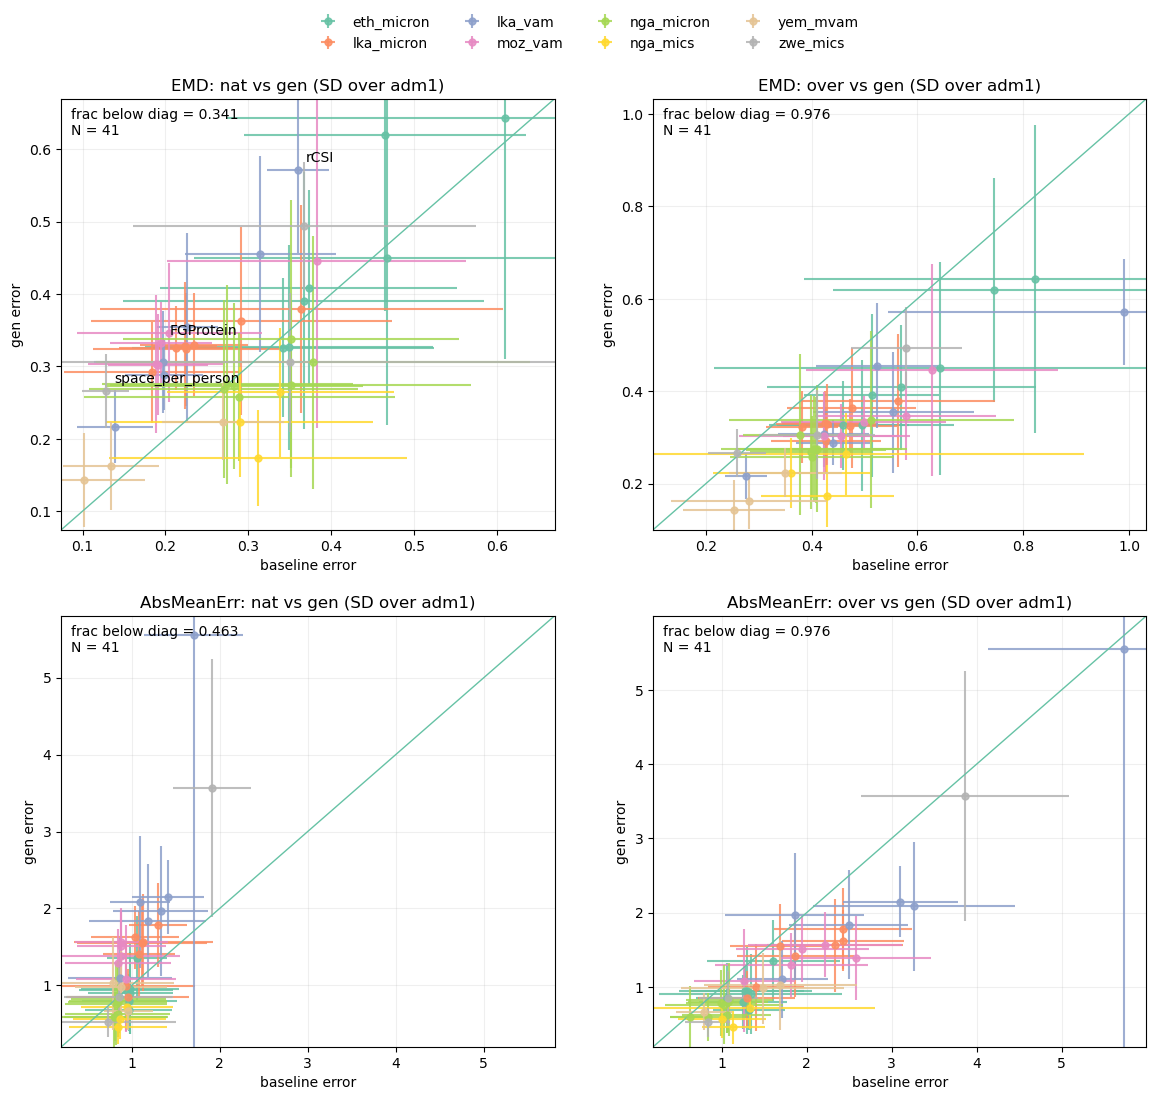

In [11]:
# plot + label points far above diagonal (y - yerr > x + xerr)
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler



pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean",  "emd_gen_sd",  "EMD: nat vs gen (SD over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean",  "emd_gen_sd",  "EMD: over vs gen (SD over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: nat vs gen (SD over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: over vs gen (SD over adm1)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(var_exp["experiment_id"].unique())

for ax, (xmean, xse, ymean, yse, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none", alpha=0.85, markersize=5,
            label=exp_id
        )

    # diagonal and bounds
    x = var_exp[xmean].to_numpy()
    y = var_exp[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    # label points clearly above diagonal (no bar intersection)
    tmp = var_exp[[ "experiment_id", "target", xmean, xse, ymean, yse ]].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna(subset=[xmean, ymean])

    mask = (tmp[ymean] - tmp[yse]) > (tmp[xmean] + tmp[xse])
    out = tmp[mask].copy()

    for _, r in out.iterrows():
        ax.annotate(
            str(r["target"]),
            (r[xmean], r[ymean]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.9)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

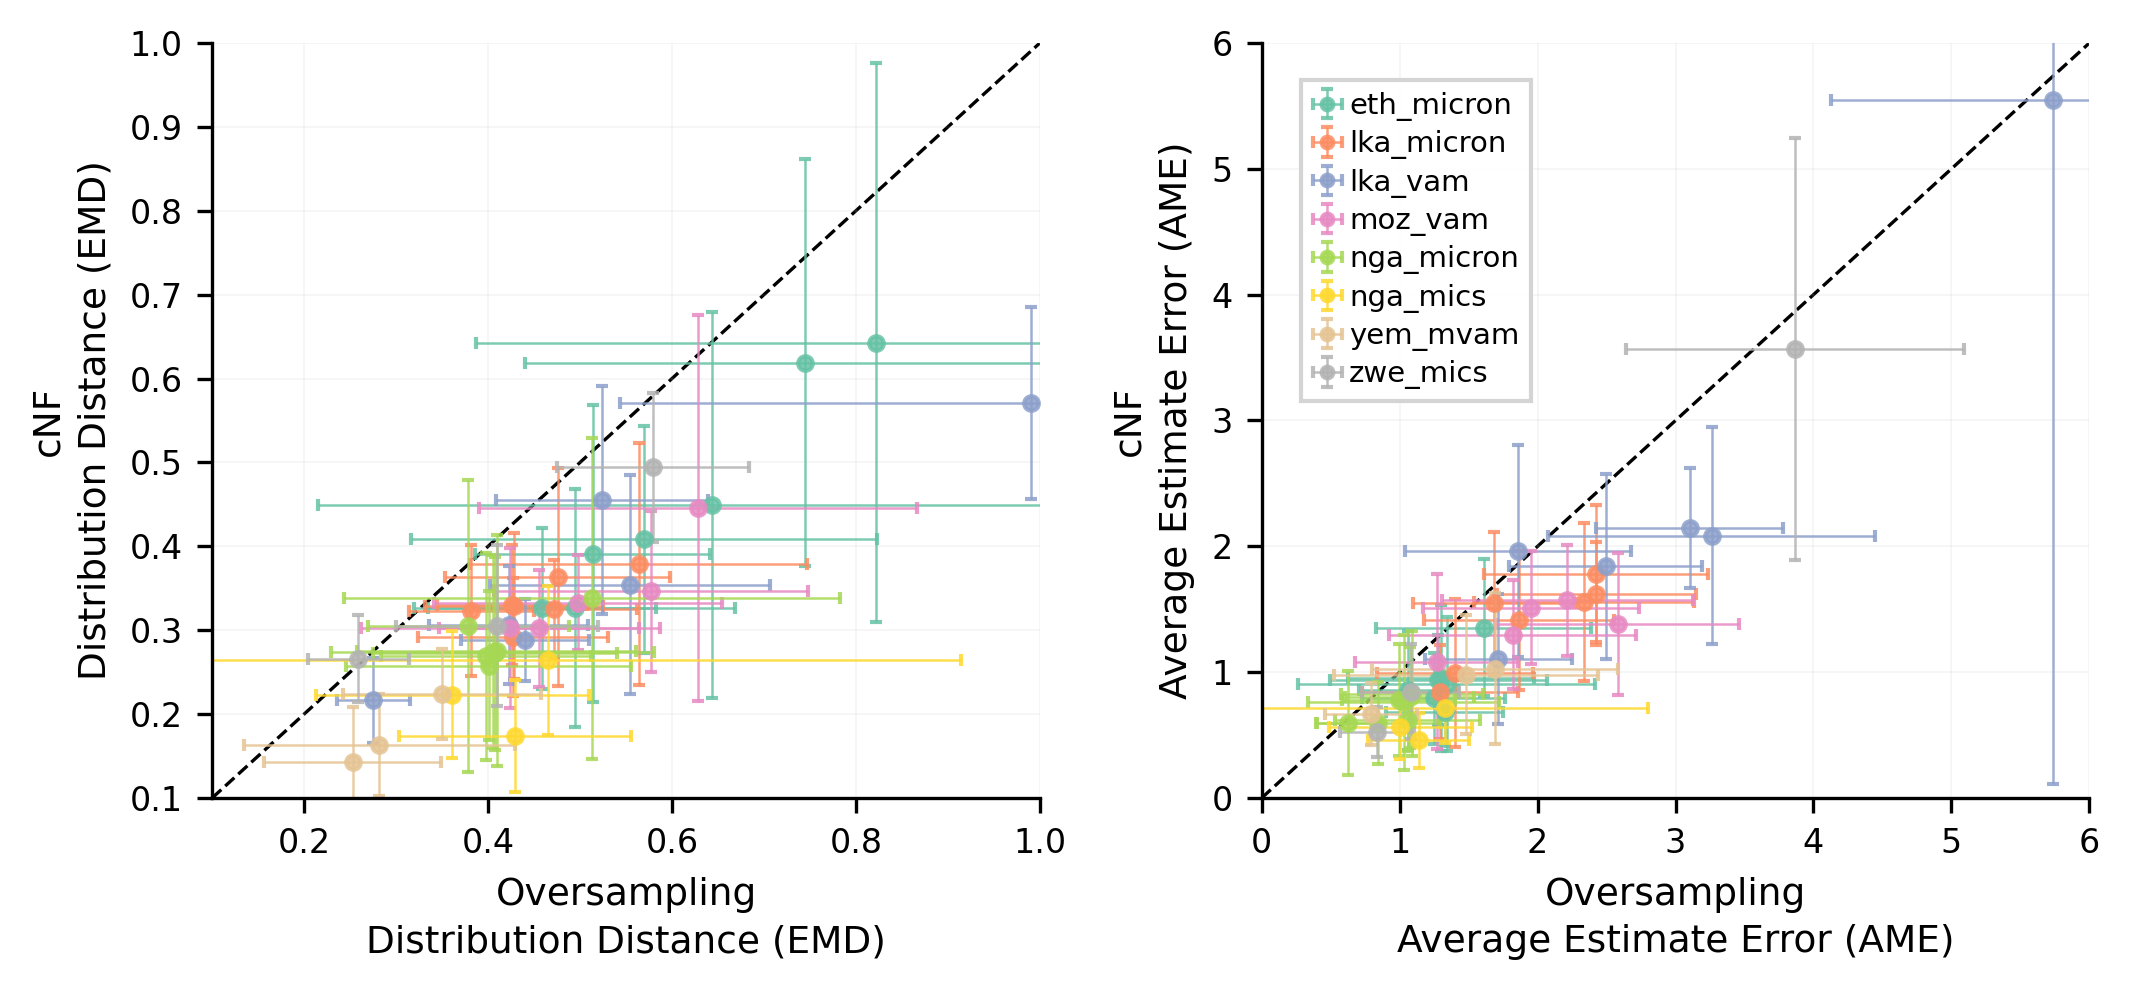

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean",  "emd_gen_sd",  "EMD: nat vs gen (SE over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean",  "emd_gen_sd",  "EMD: over vs gen (SE over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: nat vs gen (SE over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: over vs gen (SE over adm1)"),
]
pairs_right = [pairs[1], pairs[3]]

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", plt.get_cmap("Set2").colors),
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), dpi=300)
axes = np.atleast_1d(axes)

exp_ids = sorted(var_exp["experiment_id"].unique())

xlabels = [
    "Oversampling\nDistribution Distance (EMD)",
    "Oversampling\nAverage Estimate Error (AME)",
]
ylabels = [
    "cNF\nDistribution Distance (EMD)",
    "cNF\nAverage Estimate Error (AME)",
]
xlims = [(0.1, 1), (0, 6)]
ylims = [(0.1, 1), (0, 6)]

for ax, (xmean, xse, ymean, yse, _), xlim, ylim, xlab, ylab in zip(
    axes, pairs_right, xlims, ylims, xlabels, ylabels
):
    lo, hi = xlim
    ax.set_xlim(lo, hi)
    ax.set_ylim(*ylim)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8, zorder=1)

    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none",
            markersize=3.5,
            alpha=0.85,
            elinewidth=0.6,
            capsize=1.5,
            zorder=2,
            label=exp_id,
        )

    ax.set_title("")
    ax.set_xlabel(xlab, linespacing=1.4)
    ax.set_ylabel(ylab, linespacing=1.4)
    ax.grid(True, alpha=0.12, linewidth=0.4)

# legend in the upper-left triangle of the right panel (above the diagonal)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(0.03, 0.97),
    ncol=1,
    frameon=True,
    framealpha=0.92,
    edgecolor="0.82",
    fancybox=False,
    fontsize=7,
    handlelength=1.0,
    handletextpad=0.25,
    labelspacing=0.32,
    borderpad=0.4,
    markerscale=0.8,
)
plt.savefig(OUT_DIR / "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/diag.pdf", bbox_inches="tight")
fig.tight_layout(pad=1.2)
plt.show()

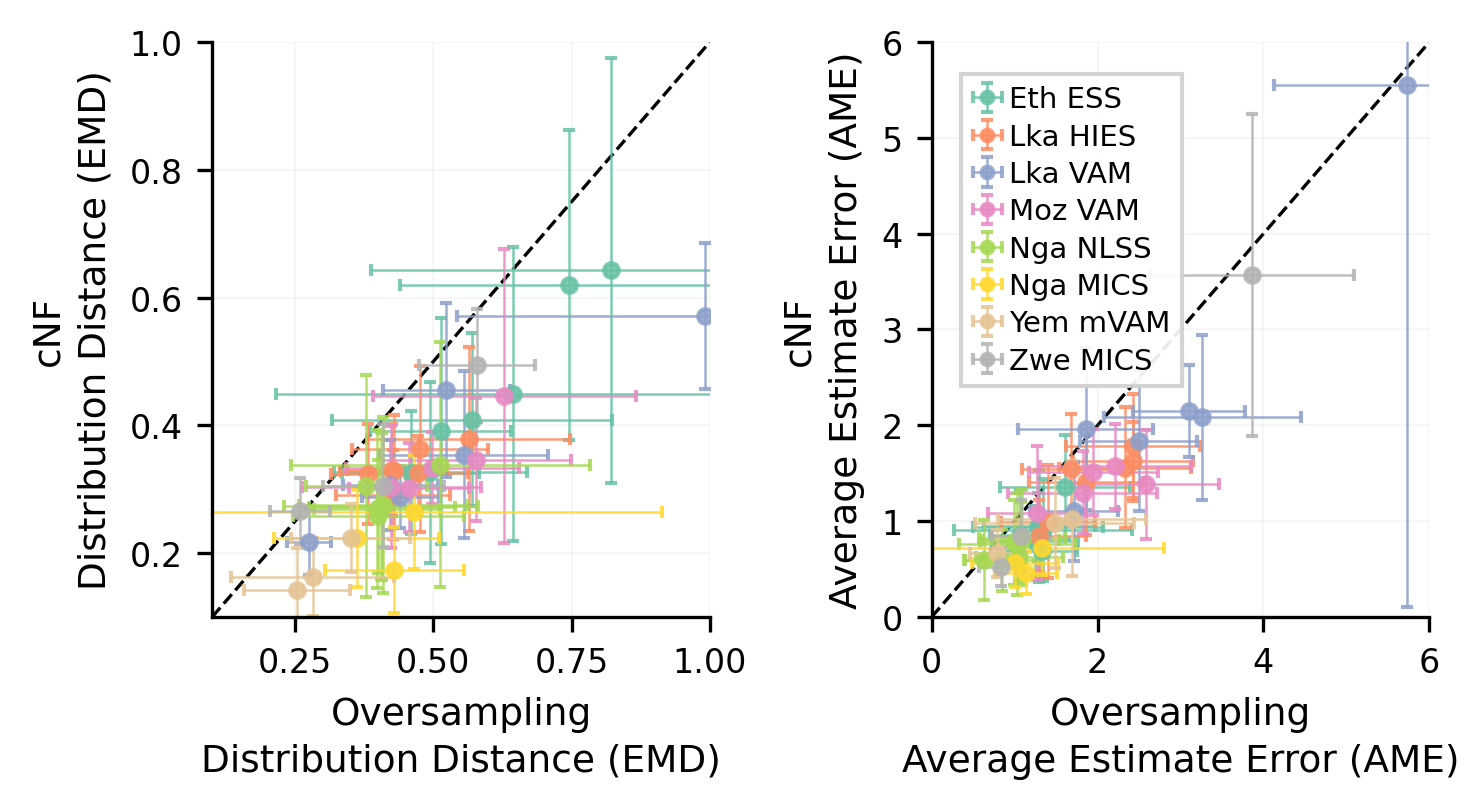

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

EXPERIMENT_LABELS = {
    "eth_micron": "Eth ESS",
    "lka_micron": "Lka HIES",
    "lka_vam":    "Lka VAM",
    "moz_vam":    "Moz VAM",
    "nga_micron": "Nga NLSS",
    "nga_mics":   "Nga MICS",
    "yem_mvam":   "Yem mVAM",
    "zwe_mics":   "Zwe MICS",
}

pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean", "emd_gen_sd",  "EMD: nat vs gen (SE over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean", "emd_gen_sd",  "EMD: over vs gen (SE over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean", "abs_gen_sd",  "AbsMeanErr: nat vs gen (SE over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean", "abs_gen_sd",  "AbsMeanErr: over vs gen (SE over adm1)"),
]
pairs_right = [pairs[1], pairs[3]]

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler("color", plt.get_cmap("Set2").colors),
})

fig, axes = plt.subplots(1, 2, figsize=(5., 2.8), dpi=300)
axes = np.atleast_1d(axes)

exp_ids = sorted(var_exp["experiment_id"].unique())

xlabels = ["Oversampling\nDistribution Distance (EMD)", "Oversampling\nAverage Estimate Error (AME)"]
ylabels = ["cNF\nDistribution Distance (EMD)",           "cNF\nAverage Estimate Error (AME)"]
xlims   = [(0.1, 1), (0, 6)]
ylims   = [(0.1, 1), (0, 6)]

for ax, (xmean, xse, ymean, yse, _), xlim, ylim, xlab, ylab in zip(
    axes, pairs_right, xlims, ylims, xlabels, ylabels
):
    lo, hi = xlim
    ax.set_xlim(lo, hi)
    ax.set_ylim(*ylim)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=0.8, zorder=1)

    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none",
            markersize=3.5, alpha=0.85,
            elinewidth=0.6, capsize=1.5,
            zorder=2,
            label=EXPERIMENT_LABELS.get(exp_id, exp_id),
        )

    ax.set_xlabel(xlab, linespacing=1.4)
    ax.set_ylabel(ylab, linespacing=1.4)
    ax.grid(True, alpha=0.12, linewidth=0.4)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles, labels,
    loc="upper left",
    bbox_to_anchor=(0.03, 0.97),
    ncol=1,
    frameon=True, framealpha=0.92, edgecolor="0.82", fancybox=False,
    fontsize=7,
    handlelength=1.0, handletextpad=0.25, labelspacing=0.32,
    borderpad=0.4, markerscale=0.8,
)

fig.tight_layout(pad=1.2)
plt.savefig(OUT_DIR / "diag.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "diag.png", dpi=300, bbox_inches="tight")
plt.show()

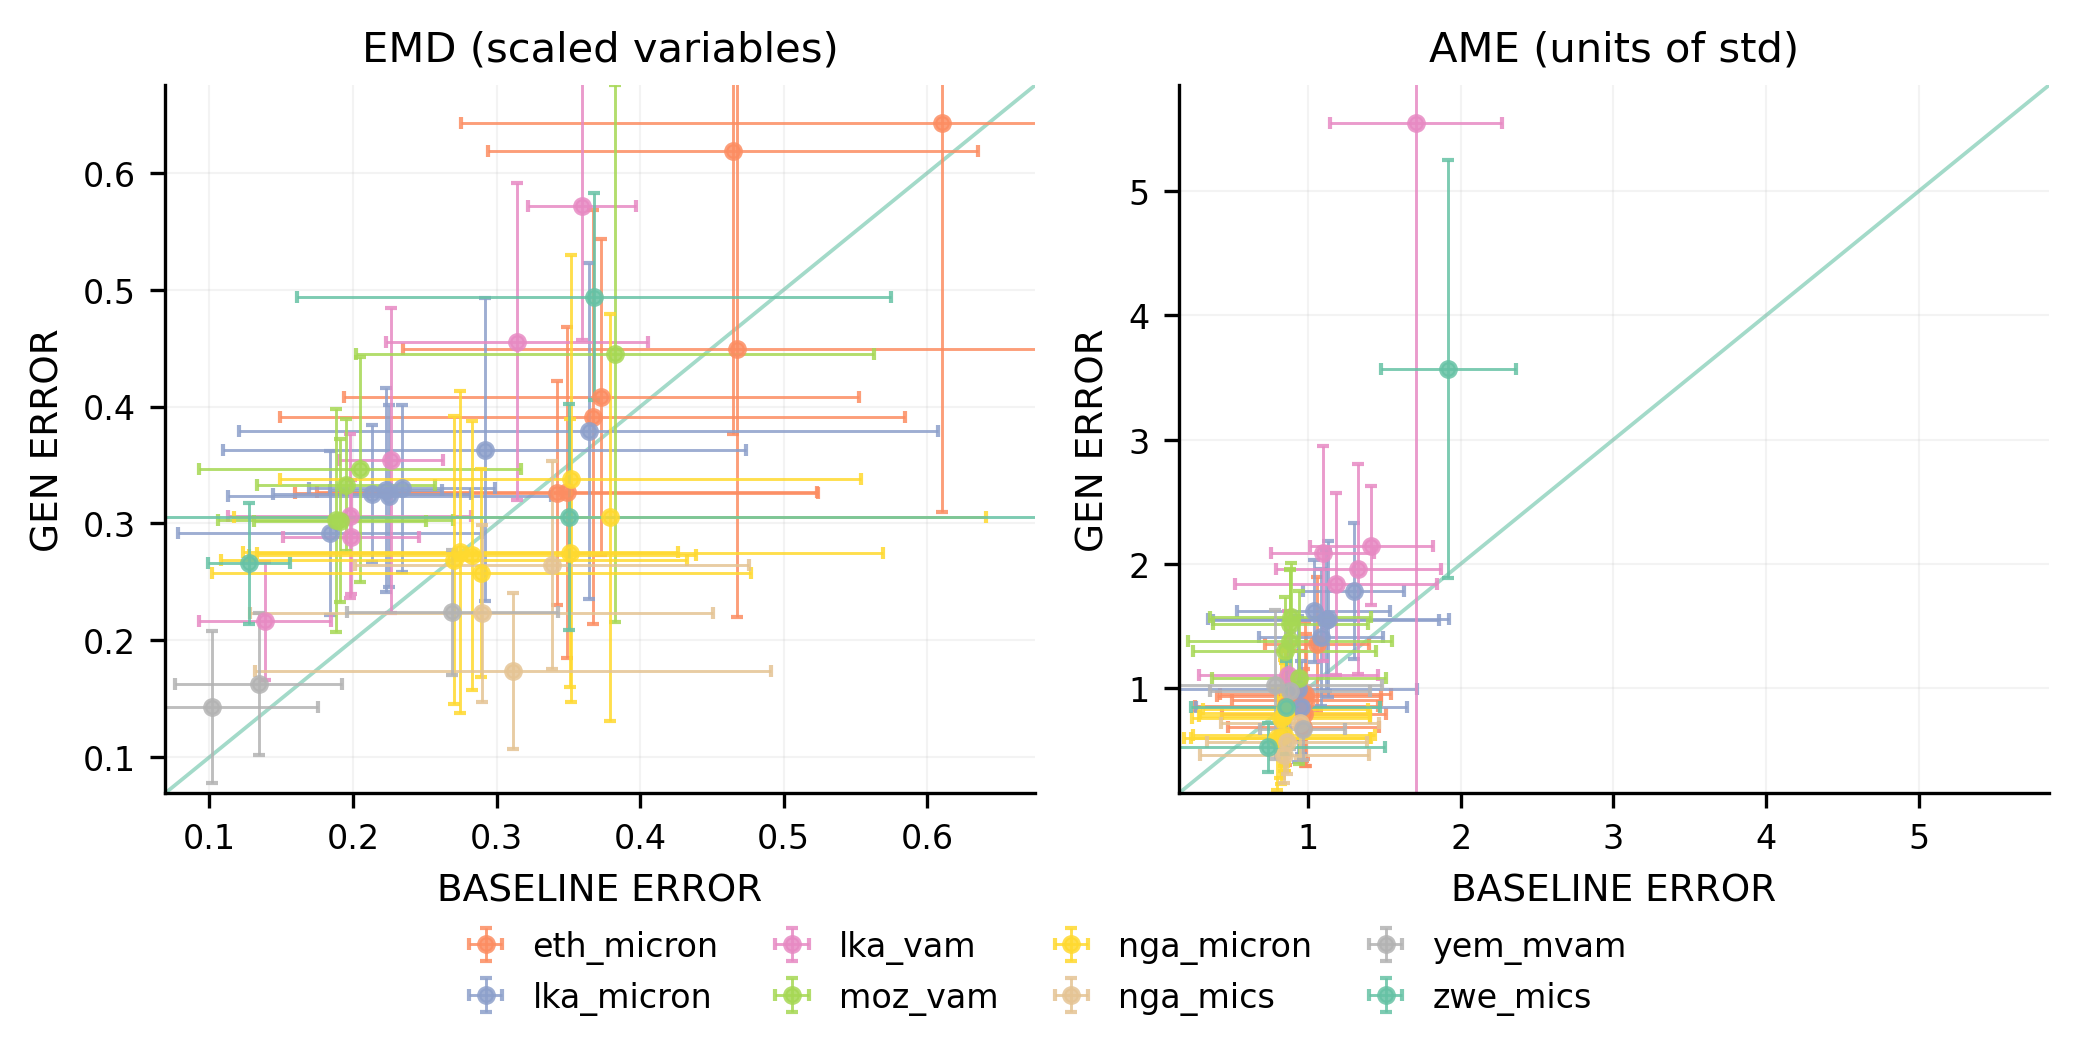

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# keep your original pairs list
pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean",  "emd_gen_sd",  "EMD: nat vs gen (SD over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean",  "emd_gen_sd",  "EMD: over vs gen (SD over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: nat vs gen (SD over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: over vs gen (SD over adm1)"),
]

# ONLY the two right panels from your original 2x2: indices 1 and 3
pairs_right = [pairs[0], pairs[2]]

# paper-ish defaults
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2), dpi=300)
axes = np.atleast_1d(axes)

exp_ids = sorted(var_exp["experiment_id"].unique())

# --- keep SAME colors as before: use your mapping if available, otherwise Matplotlib's default cycle
# If you already have exp_color_map from your maps, this will enforce it.
if "exp_color_map" in globals():
    color_map = exp_color_map
else:
    # fallback: stable colors from current rcParams cycle
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {eid: cycle[i % len(cycle)] for i, eid in enumerate(exp_ids)} if cycle else {}

titles = ["EMD (scaled variables)", "AME (units of std)"]

for ax, (xmean, xse, ymean, yse, _), st in zip(axes, pairs_right, titles):
    # bounds + diagonal (no extra text, no labels)
    x = var_exp[xmean].to_numpy()
    y = var_exp[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.06 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], linewidth=0.9, alpha=0.6, zorder=1)

    # points + errorbars (colored by experiment with fixed mapping)
    for exp_id in exp_ids:
        d = var_exp[var_exp["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xse], yerr=d[yse],
            fmt="o", linestyle="none",
            markersize=3.5,
            alpha=0.85,
            elinewidth=0.7,
            capsize=1.5,
            zorder=2,
            label=exp_id
        )

    ax.set_title(st, pad=6)
    ax.set_xlabel("BASELINE ERROR")
    ax.set_ylabel("GEN ERROR")
    ax.grid(True, alpha=0.15, linewidth=0.5)

# shared legend BELOW with extra space
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),   # lower => more breathing room
    ncol=min(4, len(exp_ids)),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4
)

# leave more bottom margin for legend
fig.tight_layout()
plt.show()

# optional export
# fig.savefig("scatter_over_vs_gen.pdf", bbox_inches="tight")
# fig.savefig("scatter_over_vs_gen.png", dpi=600, bbox_inches="tight")

with std dev instead of std error

In [15]:
# aggregate across adm1: mean across adm1 + SD over adm1 (SD across adm1)
import numpy as np
import pandas as pd

keys_var = ["experiment_id","country","dataset","train_percent_int","target"]

def _sd_over_adm1(x: pd.Series) -> float:
    n = x.shape[0]
    if n <= 1:
        return 0.0
    return float(x.std(ddof=1))

var_exp_sd = (
    adm1_seedmean.groupby(keys_var, as_index=False)
    .agg(
        n_adm1=("adm1_code","nunique"),

        emd_gen_mean=("emd_gen_mean","mean"),
        emd_nat_mean=("emd_nat_mean","mean"),
        emd_over_mean=("emd_over_mean","mean"),

        abs_gen_mean=("abs_gen_mean","mean"),
        abs_nat_mean=("abs_nat_mean","mean"),
        abs_over_mean=("abs_over_mean","mean"),

        emd_gen_sd=("emd_gen_mean", _sd_over_adm1),
        emd_nat_sd=("emd_nat_mean", _sd_over_adm1),
        emd_over_sd=("emd_over_mean", _sd_over_adm1),

        abs_gen_sd=("abs_gen_mean", _sd_over_adm1),
        abs_nat_sd=("abs_nat_mean", _sd_over_adm1),
        abs_over_sd=("abs_over_mean", _sd_over_adm1),
    )
)

var_exp_sd.head()

,experiment_id,country,dataset,train_percent_int,target,n_adm1,emd_gen_mean,emd_nat_mean,emd_over_mean,abs_gen_mean,abs_nat_mean,abs_over_mean,emd_gen_sd,emd_nat_sd,emd_over_sd,abs_gen_sd,abs_nat_sd,abs_over_sd
0,eth_micron,eth,micron,1,avg_adult_education,11,0.325904,0.341745,0.458787,0.686541,0.968984,1.326388,0.096006,0.182390,0.124264,0.272299,0.493875,0.423894
1,eth_micron,eth,micron,1,fe_ai,11,0.390958,0.367028,0.513749,0.854727,0.857837,1.061332,0.176945,0.217723,0.127456,0.469870,0.600894,0.358328
2,eth_micron,eth,micron,1,fol_ai,11,0.449282,0.467211,0.643172,0.905264,0.987986,1.342527,0.229690,0.232712,0.428410,0.534315,0.487059,1.076475
3,eth_micron,eth,micron,1,log_exp,11,0.326498,0.348894,0.494241,0.791942,0.974722,1.248337,0.141660,0.173999,0.174796,0.363053,0.537849,0.518041
4,eth_micron,eth,micron,1,va_ai,11,0.642691,0.610436,0.821649,0.951564,0.982126,1.297925,0.332878,0.335579,0.435274,0.581988,0.559903,0.672878


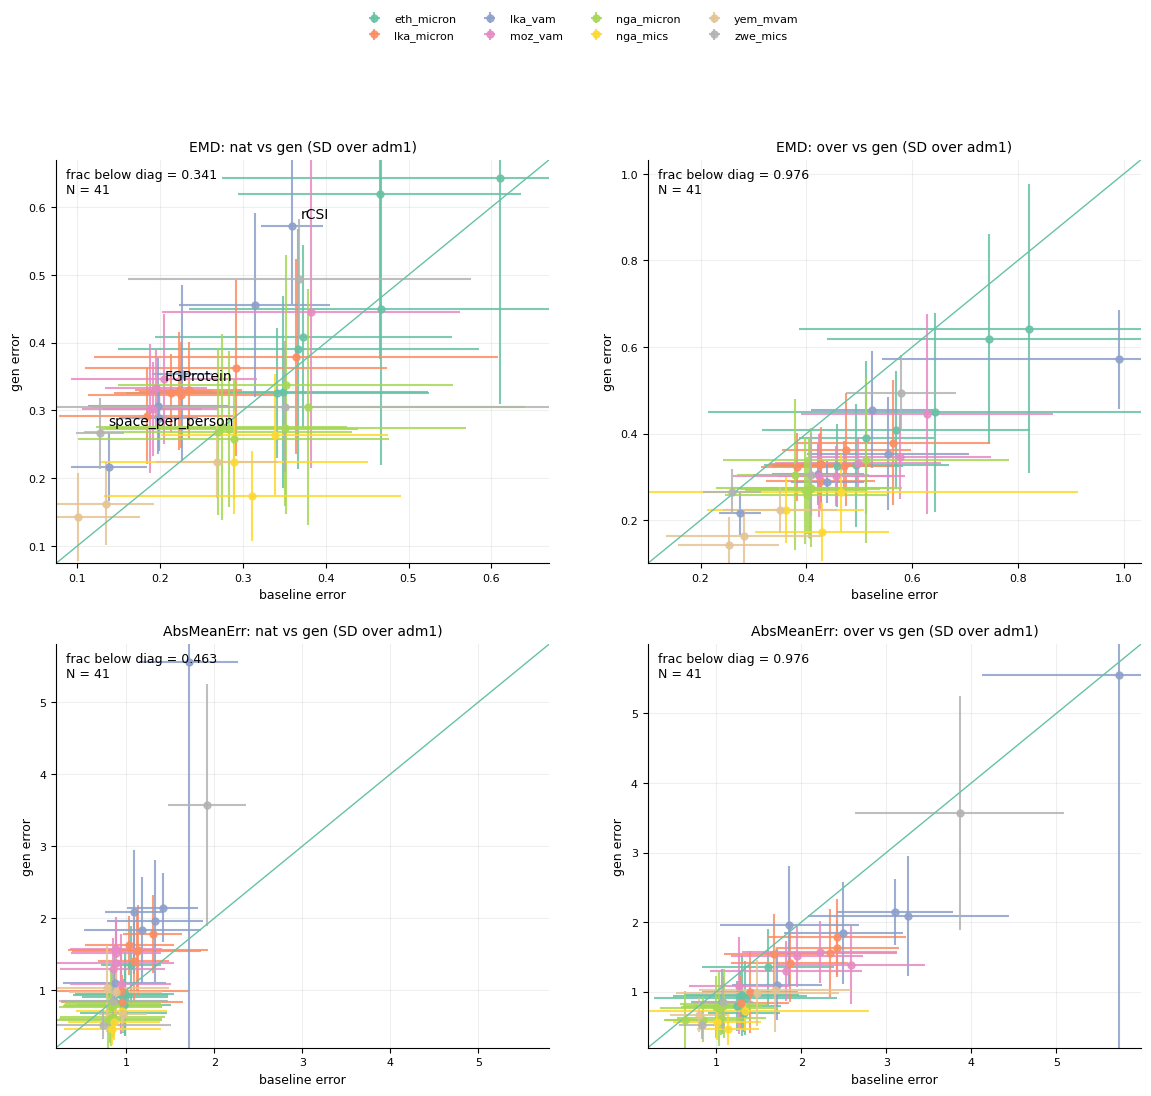

In [16]:
# plot + label points clearly above diagonal using SD bars over adm1
import matplotlib.pyplot as plt
import numpy as np

pairs = [
    ("emd_nat_mean",  "emd_nat_sd",  "emd_gen_mean",  "emd_gen_sd",  "EMD: nat vs gen (SD over adm1)"),
    ("emd_over_mean", "emd_over_sd", "emd_gen_mean",  "emd_gen_sd",  "EMD: over vs gen (SD over adm1)"),
    ("abs_nat_mean",  "abs_nat_sd",  "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: nat vs gen (SD over adm1)"),
    ("abs_over_mean", "abs_over_sd", "abs_gen_mean",  "abs_gen_sd",  "AbsMeanErr: over vs gen (SD over adm1)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

exp_ids = sorted(var_exp_sd["experiment_id"].unique())

for ax, (xmean, xsd, ymean, ysd, title) in zip(axes, pairs):
    # points + errorbars (colored by experiment)
    for exp_id in exp_ids:
        d = var_exp_sd[var_exp_sd["experiment_id"] == exp_id]
        ax.errorbar(
            d[xmean], d[ymean],
            xerr=d[xsd], yerr=d[ysd],
            fmt="o", linestyle="none", alpha=0.85, markersize=5,
            label=exp_id
        )

    # diagonal + bounds + fraction below
    x = var_exp_sd[xmean].to_numpy()
    y = var_exp_sd[ymean].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]

    if len(x) > 0:
        lo = float(np.nanmin(np.r_[x, y]))
        hi = float(np.nanmax(np.r_[x, y]))
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        lo -= pad; hi += pad
        ax.plot([lo, hi], [lo, hi], linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        frac_below = float(np.mean(y < x))
        ax.text(
            0.02, 0.98,
            f"frac below diag = {frac_below:.3f}\nN = {len(x)}",
            transform=ax.transAxes,
            va="top"
        )

    # label points clearly above diagonal (no bar intersection)
    tmp = var_exp_sd[[ "experiment_id", "target", xmean, xsd, ymean, ysd ]].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna(subset=[xmean, ymean])

    mask = (tmp[ymean] - tmp[ysd]) > (tmp[xmean] + tmp[xsd])
    out = tmp[mask].copy()

    for _, r in out.iterrows():
        ax.annotate(
            str(r["target"]),
            (r[xmean], r[ymean]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("baseline error")
    ax.set_ylabel("gen error")
    ax.grid(True, alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.85)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)

plt.show()

## Maps visualization

In [17]:
# prep geodata + improvement table (avg over seeds already done at adm1 level)
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt

# 1) merge geometry back at adm1 level
g = geom_lookup[["experiment_id","adm1_code","adm1geometry"]].drop_duplicates(["experiment_id","adm1_code"]).copy()

adm1_seedmean_geo = (
    adm1_seedmean
    .merge(g, on=["experiment_id","adm1_code"], how="left")
)

adm1_seedmean_geo["geometry"] = adm1_seedmean_geo["adm1geometry"].apply(lambda s: wkt.loads(s) if isinstance(s, str) and len(s) else None)
gdf = gpd.GeoDataFrame(adm1_seedmean_geo.drop(columns=["adm1geometry"]), geometry="geometry", crs="EPSG:4326")

# 2) improvements (baseline - gen)
gdf["imp_emd_nat"]  = gdf["emd_nat_mean"]  - gdf["emd_gen_mean"]
gdf["imp_emd_over"] = gdf["emd_over_mean"] - gdf["emd_gen_mean"]
gdf["imp_abs_nat"]  = gdf["abs_nat_mean"]  - gdf["abs_gen_mean"]
gdf["imp_abs_over"] = gdf["abs_over_mean"] - gdf["abs_gen_mean"]

# layout sets
exp_ids = sorted(gdf["experiment_id"].unique().tolist())
targets_all = sorted(gdf["target"].unique().tolist())

len(exp_ids), len(targets_all)

(8, 23)

In [18]:
cmap_exp = plt.get_cmap('Set2')
exp_colors = cmap_exp(np.linspace(0.05, 0.85, len(exp_ids)))
exp_color_map = {exp: exp_colors[i] for i, exp in enumerate(exp_ids)}

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

cmap_rwg = LinearSegmentedColormap.from_list("rwg", ["#d7191c", "#ffffff", "#1a9641"])

targets_by_exp = {
    exp: sorted(gdf.loc[gdf["experiment_id"] == exp, "target"].dropna().unique().tolist())
    for exp in exp_ids
}

def plot_improvement(
    gdf,
    value_col,
    fig_title,
    vlim_percentile=98,
    box_lw=3.0,
    title_fs=22,
    exp_fs=22,     # big like before
    var_fs=15,
    header_h=0.28,
    row_hspace=0.08,   # << less space between boxes
    col_wspace=0.12,
    title_band=0.25,
    cb_band=0.20,      # << smaller cb area

    # sizing similar to your original
    map_w=3.3,
    row_h=4.2,

    # fixed label column width (relative to a map col)
    label_col_w=0.42,

    # colorbar shorter + thinner (x,y,w,h inside cb band axis)
    cb_inset = (0.38, 0.54, 0.26, 0.25),
):
    vals = gdf[value_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if vals.size == 0:
        print(f"no data for {value_col}")
        return

    vmax = float(np.nanpercentile(np.abs(vals), vlim_percentile))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(vals))) if float(np.nanmax(np.abs(vals))) > 0 else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    n_exp = len(exp_ids)
    max_cols = max(len(targets_by_exp[e]) for e in exp_ids)

    fig = plt.figure(figsize=(map_w * (max_cols + label_col_w), row_h * n_exp))

    outer = GridSpec(
        nrows=n_exp + 2, ncols=1, figure=fig,
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace
    )

    # --- title band ---
    ax_title = fig.add_subplot(outer[0, 0])
    ax_title.axis("off")
    ax_title.text(
        0.5, 0.55, str(fig_title).upper(),
        ha="center", va="center",
        fontsize=title_fs, fontweight="bold"
    )

    # --- experiment rows ---
    for i, exp_id in enumerate(exp_ids, start=1):
        tgts = targets_by_exp[exp_id]
        ncols = len(tgts)
        box_color = exp_color_map.get(exp_id, "black")

        # FIXED grid per row: 2 rows, (1 label col + max_cols map cols)
        inner = GridSpecFromSubplotSpec(
            nrows=2, ncols=max_cols + 1,
            subplot_spec=outer[i, 0],
            height_ratios=[header_h, 1.0],
            width_ratios=[label_col_w] + [1.0] * max_cols,
            wspace=col_wspace,
            hspace=0.0
        )

        row_axes = []

        # label axis spanning both rows (vertical, colored, large)
        ax_lab = fig.add_subplot(inner[:, 0])
        ax_lab.axis("off")
        ax_lab.text(
            0.10, 0.5, exp_id,
            rotation=90,
            ha="left", va="center",
            fontsize=exp_fs, fontweight="bold",
            color=box_color,
            transform=ax_lab.transAxes
        )
        row_axes.append(ax_lab)

        # headers and maps for existing targets; blanks for the rest to keep alignment
        for j in range(max_cols):
            col = j + 1

            # header
            ax_h = fig.add_subplot(inner[0, col])
            ax_h.axis("off")
            if j < ncols:
                ax_h.text(0.5, 0.7, str(tgts[j]), ha="center", va="center", fontsize=var_fs)
            row_axes.append(ax_h)

            # map
            ax_m = fig.add_subplot(inner[1, col])
            ax_m.set_axis_off()
            row_axes.append(ax_m)

            if j >= ncols:
                continue

            tgt = tgts[j]
            sub = gdf[(gdf["experiment_id"] == exp_id) & (gdf["target"] == tgt)]
            if sub.empty or sub["geometry"].isna().all():
                continue

            sub.plot(
                column=value_col,
                ax=ax_m,
                cmap=cmap_rwg,
                norm=norm,
                linewidth=0.25,
                edgecolor="white",
                legend=False,
            )

        # border around the whole row (no awkward overlay)
        bbox = Bbox.union([ax.get_position() for ax in row_axes])
        fig.add_artist(
            Rectangle(
                (bbox.x0, bbox.y0), bbox.width, bbox.height,
                transform=fig.transFigure,
                fill=False, edgecolor=box_color, linewidth=box_lw
            )
        )

    # --- colorbar band (shorter + thinner) ---
    ax_cb = fig.add_subplot(outer[-1, 0])
    ax_cb.axis("off")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_rwg)
    sm.set_array([])

    cb_ax = ax_cb.inset_axes(list(cb_inset))
    cb = fig.colorbar(sm, cax=cb_ax, orientation="horizontal")
    cb.set_label("BASELINE - GEN", fontsize=15)
    cb.ax.tick_params(labelsize=9)

    plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

cmap_rwg = LinearSegmentedColormap.from_list("rwg", ["#d7191c", "#ffffff", "#1a9641"])

targets_by_exp = {
    exp: sorted(gdf.loc[gdf["experiment_id"] == exp, "target"].dropna().unique().tolist())
    for exp in exp_ids
}

def plot_improvement(
    gdf,
    value_col,
    fig_title,
    vlim_percentile=98,
    box_lw=3.0,
    title_fs=22,
    exp_fs=22,
    var_fs=15,
    header_h=0.28,
    row_hspace=0.08,
    col_wspace=0.12,
    title_band=0.25,
    cb_band=0.20,
    map_w=3.3,
    row_h=4.2,
    label_col_w=0.42,
    overall_col_w=1.4,      # << wider than a normal map col
    overall_gap=0.18,        # << gap between boxes and overall column
    cb_inset=(0.38, 0.54, 0.26, 0.25),
):
    vals = gdf[value_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if vals.size == 0:
        print(f"no data for {value_col}")
        return

    vmax = float(np.nanpercentile(np.abs(vals), vlim_percentile))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(vals))) if float(np.nanmax(np.abs(vals))) > 0 else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    n_exp = len(exp_ids)
    max_cols = max(len(targets_by_exp[e]) for e in exp_ids)

    # Precompute per-region average across all targets for each experiment
    overall_by_exp = {}
    for exp_id in exp_ids:
        sub = gdf[gdf["experiment_id"] == exp_id][["geometry", value_col]].copy()
        # average over targets by dissolving on geometry index
        sub = sub.dropna(subset=[value_col])
        if not sub.empty:
            avg = (
                gdf[gdf["experiment_id"] == exp_id]
                .groupby(gdf[gdf["experiment_id"] == exp_id].index)[value_col]
                .mean()
            )
            overall_gdf = gdf[gdf["experiment_id"] == exp_id].copy()
            overall_gdf = overall_gdf.drop_duplicates(subset=["geometry"])
            # map index -> mean value
            overall_gdf[value_col] = (
                gdf[gdf["experiment_id"] == exp_id]
                .groupby(level=0)[value_col]
                .mean()
                .reindex(overall_gdf.index)
            )
            overall_by_exp[exp_id] = overall_gdf
        else:
            overall_by_exp[exp_id] = sub

    # Figure width: box area + gap + overall col
    box_area_w = map_w * (max_cols + label_col_w)
    overall_w   = map_w * overall_col_w
    total_w     = box_area_w + map_w * overall_gap + overall_w

    fig = plt.figure(figsize=(total_w, row_h * n_exp))

    # ── Outer layout: left (box area) | right (overall column) ──────────────
    # We use a top-level GridSpec with 2 columns
    root = GridSpec(
        nrows=1, ncols=2, figure=fig,
        width_ratios=[box_area_w, overall_w],
        wspace=overall_gap / (max_cols + label_col_w),
    )

    left_gs  = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 0],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )
    right_gs = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 1],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )

    # ── Title band ────────────────────────────────────────────────────────────
    ax_title = fig.add_subplot(left_gs[0, 0])
    ax_title.axis("off")
    ax_title.text(
        0.5, 0.55, str(fig_title).upper(),
        ha="center", va="center",
        fontsize=title_fs, fontweight="bold"
    )

    # "Overall" column header (spans title band on the right)
    ax_overall_title = fig.add_subplot(right_gs[0, 0])
    ax_overall_title.axis("off")
    ax_overall_title.text(
        0.5, 0.55, "OVERALL",
        ha="center", va="center",
        fontsize=title_fs * 0.85, fontweight="bold", color="dimgrey"
    )

    # ── Experiment rows ───────────────────────────────────────────────────────
    for i, exp_id in enumerate(exp_ids, start=1):
        tgts    = targets_by_exp[exp_id]
        ncols   = len(tgts)
        box_color = exp_color_map.get(exp_id, "black")

        # ── Left: boxed per-variable maps ────────────────────────────────────
        inner = GridSpecFromSubplotSpec(
            nrows=2, ncols=max_cols + 1,
            subplot_spec=left_gs[i, 0],
            height_ratios=[header_h, 1.0],
            width_ratios=[label_col_w] + [1.0] * max_cols,
            wspace=col_wspace,
            hspace=0.0,
        )

        row_axes = []

        ax_lab = fig.add_subplot(inner[:, 0])
        ax_lab.axis("off")
        ax_lab.text(
            0.10, 0.5, exp_id,
            rotation=90, ha="left", va="center",
            fontsize=exp_fs, fontweight="bold",
            color=box_color, transform=ax_lab.transAxes
        )
        row_axes.append(ax_lab)

        for j in range(max_cols):
            col = j + 1
            ax_h = fig.add_subplot(inner[0, col])
            ax_h.axis("off")
            if j < ncols:
                ax_h.text(0.5, 0.7, str(tgts[j]), ha="center", va="center", fontsize=var_fs)
            row_axes.append(ax_h)

            ax_m = fig.add_subplot(inner[1, col])
            ax_m.set_axis_off()
            row_axes.append(ax_m)

            if j >= ncols:
                continue

            tgt = tgts[j]
            sub = gdf[(gdf["experiment_id"] == exp_id) & (gdf["target"] == tgt)]
            if sub.empty or sub["geometry"].isna().all():
                continue

            sub.plot(
                column=value_col, ax=ax_m,
                cmap=cmap_rwg, norm=norm,
                linewidth=0.25, edgecolor="white", legend=False,
            )

        # Colored border around the boxed row
        bbox = Bbox.union([ax.get_position() for ax in row_axes])
        fig.add_artist(
            Rectangle(
                (bbox.x0, bbox.y0), bbox.width, bbox.height,
                transform=fig.transFigure,
                fill=False, edgecolor=box_color, linewidth=box_lw
            )
        )

        # ── Right: overall average map (outside box, slightly bigger) ────────
        ax_overall = fig.add_subplot(right_gs[i, 0])
        ax_overall.set_axis_off()

        ov = overall_by_exp.get(exp_id)
        if ov is not None and not ov.empty and not ov["geometry"].isna().all():
            ov.plot(
                column=value_col, ax=ax_overall,
                cmap=cmap_rwg, norm=norm,
                linewidth=0.25, edgecolor="white", legend=False,
            )

    # ── Colorbar band ─────────────────────────────────────────────────────────
    ax_cb = fig.add_subplot(left_gs[-1, 0])
    ax_cb.axis("off")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_rwg)
    sm.set_array([])

    cb_ax = ax_cb.inset_axes(list(cb_inset))
    cb = fig.colorbar(sm, cax=cb_ax, orientation="horizontal")
    cb.set_label("BASELINE - GEN", fontsize=15)
    cb.ax.tick_params(labelsize=9)

    # blank the right cb band so it doesn't show a stray axis
    ax_cb_r = fig.add_subplot(right_gs[-1, 0])
    ax_cb_r.axis("off")

    plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

# -----------------------------------------------------------------------------
# Style
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          9,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

# -----------------------------------------------------------------------------
# Display labels (variables + experiments)
# -----------------------------------------------------------------------------
DISPLAY_LABELS = {
    "avg_adult_education": "Education",
    "fe_ai":        "Iron",
    "fol_ai":       "Folate",
    "log_exp":      "Expenditures",
    "va_ai":        "Vitamin A",
    "vb12_ai":      "Vitamin B12",
    "zn_ai":        "Zinc",
    "fe_mg":        "Iron",
    "folate_mcg":   "Folate",
    "vita_rae_mcg": "Vitamin A",
    "vitb12_mcg":   "Vitamin B12",
    "zn_mg":        "Zinc",
    "FCS":          "FCS",
    "FES":          "FES",
    "education_score": "Education",
    "log_income":   "Income",
    "rCSI":         "rCSI",
    "space_per_person": "Space pp",
    "FGHIron":      "Iron",
    "FGProtein":    "Protein",
    "FGVitA":       "Vitamin A",
    "wscore":       "Wealth Score",
    "log_exp_pp":   "Expenditures pp",
    # experiment labels
    "eth_micron":   "Ethiopia\nESS",
    "lka_micron":   "Sri Lanka\nHIES",
    "lka_vam":      "Sri Lanka\nVAM",
    "moz_vam":      "Mozambique\nVAM",
    "nga_micron":   "Nigeria\nNLSS",
    "nga_mics":     "Nigeria\nMICS",
    "yem_mvam":     "Yemen\nmVAM",
    "zwe_mics":     "Zimbabwe\nMICS",
}

# -----------------------------------------------------------------------------
# Dataset colors
# -----------------------------------------------------------------------------
DATASET_COLORS = {
    "eth_micron": "#117733",
    "lka_micron": "#EE7733",
    "lka_vam":    "#4477AA",
    "moz_vam":    "#CC79A7",
    "nga_micron": "#88CC44",
    "nga_mics":   "#DDCC77",
    "yem_mvam":   "#AA7744",
    "zwe_mics":   "#999999",
}

# -----------------------------------------------------------------------------
# Diverging colormap
# -----------------------------------------------------------------------------
cmap_rwg = LinearSegmentedColormap.from_list(
    "rwg_cb",
    ["#D55E00", "#FFFFFF", "#009E73"]
)

exp_color_map = {exp: DATASET_COLORS.get(exp, "#777777") for exp in exp_ids}

targets_by_exp = {
    exp: sorted(gdf.loc[gdf["experiment_id"] == exp, "target"].dropna().unique().tolist())
    for exp in exp_ids
}

def plot_improvement(
    gdf,
    value_col,
    fig_title,
    vlim_percentile=98,
    box_lw=1.0,
    var_fs=7,
    header_h=0.26,
    row_hspace=0.01,       # no gap between rows
    col_wspace=0.04,      # minimal gap between columns
    title_band=0.08,      # minimal space for "Overall" header
    cb_band=0.005,         # minimal space for colorbar
    map_w=0.75,
    row_h=1.12,
    label_col_w=0.6,
    overall_col_w=0.9,
    overall_gap=0.10,
    cb_width=0.38,
    cb_y=0.09,
):
    vals = gdf[value_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    if vals.size == 0:
        print(f"no data for {value_col}")
        return

    vmax = float(np.nanpercentile(np.abs(vals), vlim_percentile))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(vals))) if float(np.nanmax(np.abs(vals))) > 0 else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    n_exp = len(exp_ids)
    max_cols = max(len(targets_by_exp[e]) for e in exp_ids)

    # Precompute per-region average across all targets for each experiment
    overall_by_exp = {}
    for exp_id in exp_ids:
        sub = gdf[gdf["experiment_id"] == exp_id][["geometry", value_col]].copy()
        sub = sub.dropna(subset=[value_col])
        if not sub.empty:
            overall_gdf = gdf[gdf["experiment_id"] == exp_id].copy()
            overall_gdf = overall_gdf.drop_duplicates(subset=["geometry"])
            overall_gdf[value_col] = (
                gdf[gdf["experiment_id"] == exp_id]
                .groupby(level=0)[value_col]
                .mean()
                .reindex(overall_gdf.index)
            )
            overall_by_exp[exp_id] = overall_gdf
        else:
            overall_by_exp[exp_id] = sub

    # Figure dimensions
    box_area_w = map_w * (max_cols + label_col_w)
    overall_w  = map_w * overall_col_w
    total_w    = box_area_w + map_w * overall_gap + overall_w
    total_h    = row_h * n_exp

    fig = plt.figure(figsize=(total_w, total_h))

    # ── Outer layout ──────────────────────────────────────────────────────────
    root = GridSpec(
        nrows=1, ncols=2, figure=fig,
        width_ratios=[box_area_w, overall_w],
        wspace=overall_gap / (max_cols + label_col_w),
    )

    left_gs = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 0],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )
    right_gs = GridSpecFromSubplotSpec(
        nrows=n_exp + 2, ncols=1,
        subplot_spec=root[0, 1],
        height_ratios=[title_band] + [1.0] * n_exp + [cb_band],
        hspace=row_hspace,
    )

    ax_overall_title = fig.add_subplot(right_gs[0, 0])
    ax_overall_title.axis("off")
    ax_overall_title.text(
        0.5, 0.55, "Overall",
        ha="center", va="center",
        fontsize=9, 
    )

    # ── Experiment rows ───────────────────────────────────────────────────────
    for i, exp_id in enumerate(exp_ids, start=1):
        tgts      = targets_by_exp[exp_id]
        ncols     = len(tgts)
        box_color = exp_color_map.get(exp_id, "#444444")
        exp_label = DISPLAY_LABELS.get(exp_id, exp_id)

        inner = GridSpecFromSubplotSpec(
            nrows=2, ncols=max_cols + 1,
            subplot_spec=left_gs[i, 0],
            height_ratios=[header_h, 1.0],
            width_ratios=[label_col_w] + [1.0] * max_cols,
            wspace=col_wspace,
            hspace=0.0,
        )

        row_axes = []

        ax_lab = fig.add_subplot(inner[:, 0])
        ax_lab.axis("off")
        ax_lab.text(
            0.5, 0.5, exp_label,
            rotation=90, ha="center", va="center",
            fontsize=9, 
            color=box_color, transform=ax_lab.transAxes,
            multialignment="center",
        )
        row_axes.append(ax_lab)

        for j in range(max_cols):
            col  = j + 1
            ax_h = fig.add_subplot(inner[0, col])
            ax_h.axis("off")
            if j < ncols:
                tgt_display = DISPLAY_LABELS.get(tgts[j], str(tgts[j]))
                ax_h.text(
                    0.5, 0.68, tgt_display,
                    ha="center", va="center",
                    fontsize=var_fs, fontweight="normal"
                )
            row_axes.append(ax_h)

            ax_m = fig.add_subplot(inner[1, col])
            ax_m.set_axis_off()
            row_axes.append(ax_m)

            if j >= ncols:
                continue

            tgt = tgts[j]
            sub = gdf[(gdf["experiment_id"] == exp_id) & (gdf["target"] == tgt)]
            if sub.empty or sub["geometry"].isna().all():
                continue

            sub.plot(
                column=value_col, ax=ax_m,
                cmap=cmap_rwg, norm=norm,
                linewidth=0,           # no borders — prevents thick lines in PDF
                edgecolor="none",
                legend=False,
            )

        bbox = Bbox.union([ax.get_position() for ax in row_axes])
        fig.add_artist(
            Rectangle(
                (bbox.x0, bbox.y0), bbox.width, bbox.height,
                transform=fig.transFigure,
                fill=False, edgecolor=box_color, linewidth=box_lw
            )
        )

        ax_overall = fig.add_subplot(right_gs[i, 0])
        ax_overall.set_axis_off()
        ov = overall_by_exp.get(exp_id)
        if ov is not None and not ov.empty and not ov["geometry"].isna().all():
            ov.plot(
                column=value_col, ax=ax_overall,
                cmap=cmap_rwg, norm=norm,
                linewidth=0,           # no borders — prevents thick lines in PDF
                edgecolor="none",
                legend=False,
            )

    # ── Colorbar ──────────────────────────────────────────────────────────────
    ax_cb_left  = fig.add_subplot(left_gs[-1, 0])
    ax_cb_left.axis("off")
    ax_cb_right = fig.add_subplot(right_gs[-1, 0])
    ax_cb_right.axis("off")

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_rwg)
    sm.set_array([])

    cb_ax = fig.add_axes([
        0.5 - cb_width / 2,
        cb_y,
        cb_width,
        0.012
    ])

    cb = fig.colorbar(sm, cax=cb_ax, orientation="horizontal")
    cb.set_label("Baseline − cNF", fontsize=var_fs)
    cb.ax.tick_params(labelsize=var_fs, width=0.6, length=2.5)
    cb.outline.set_linewidth(0.6)

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

    # ── Save ──────────────────────────────────────────────────────────────────
    safe_title = str(fig_title).replace(" ", "_").replace("/", "_")
    fig.savefig(f"{safe_title}.png", bbox_inches="tight", dpi=400)
    fig.savefig(f"{safe_title}.pdf", bbox_inches="tight")
    fig.savefig(f"{safe_title}.svg", bbox_inches="tight")

/tmp/ipykernel_31054/314117115.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


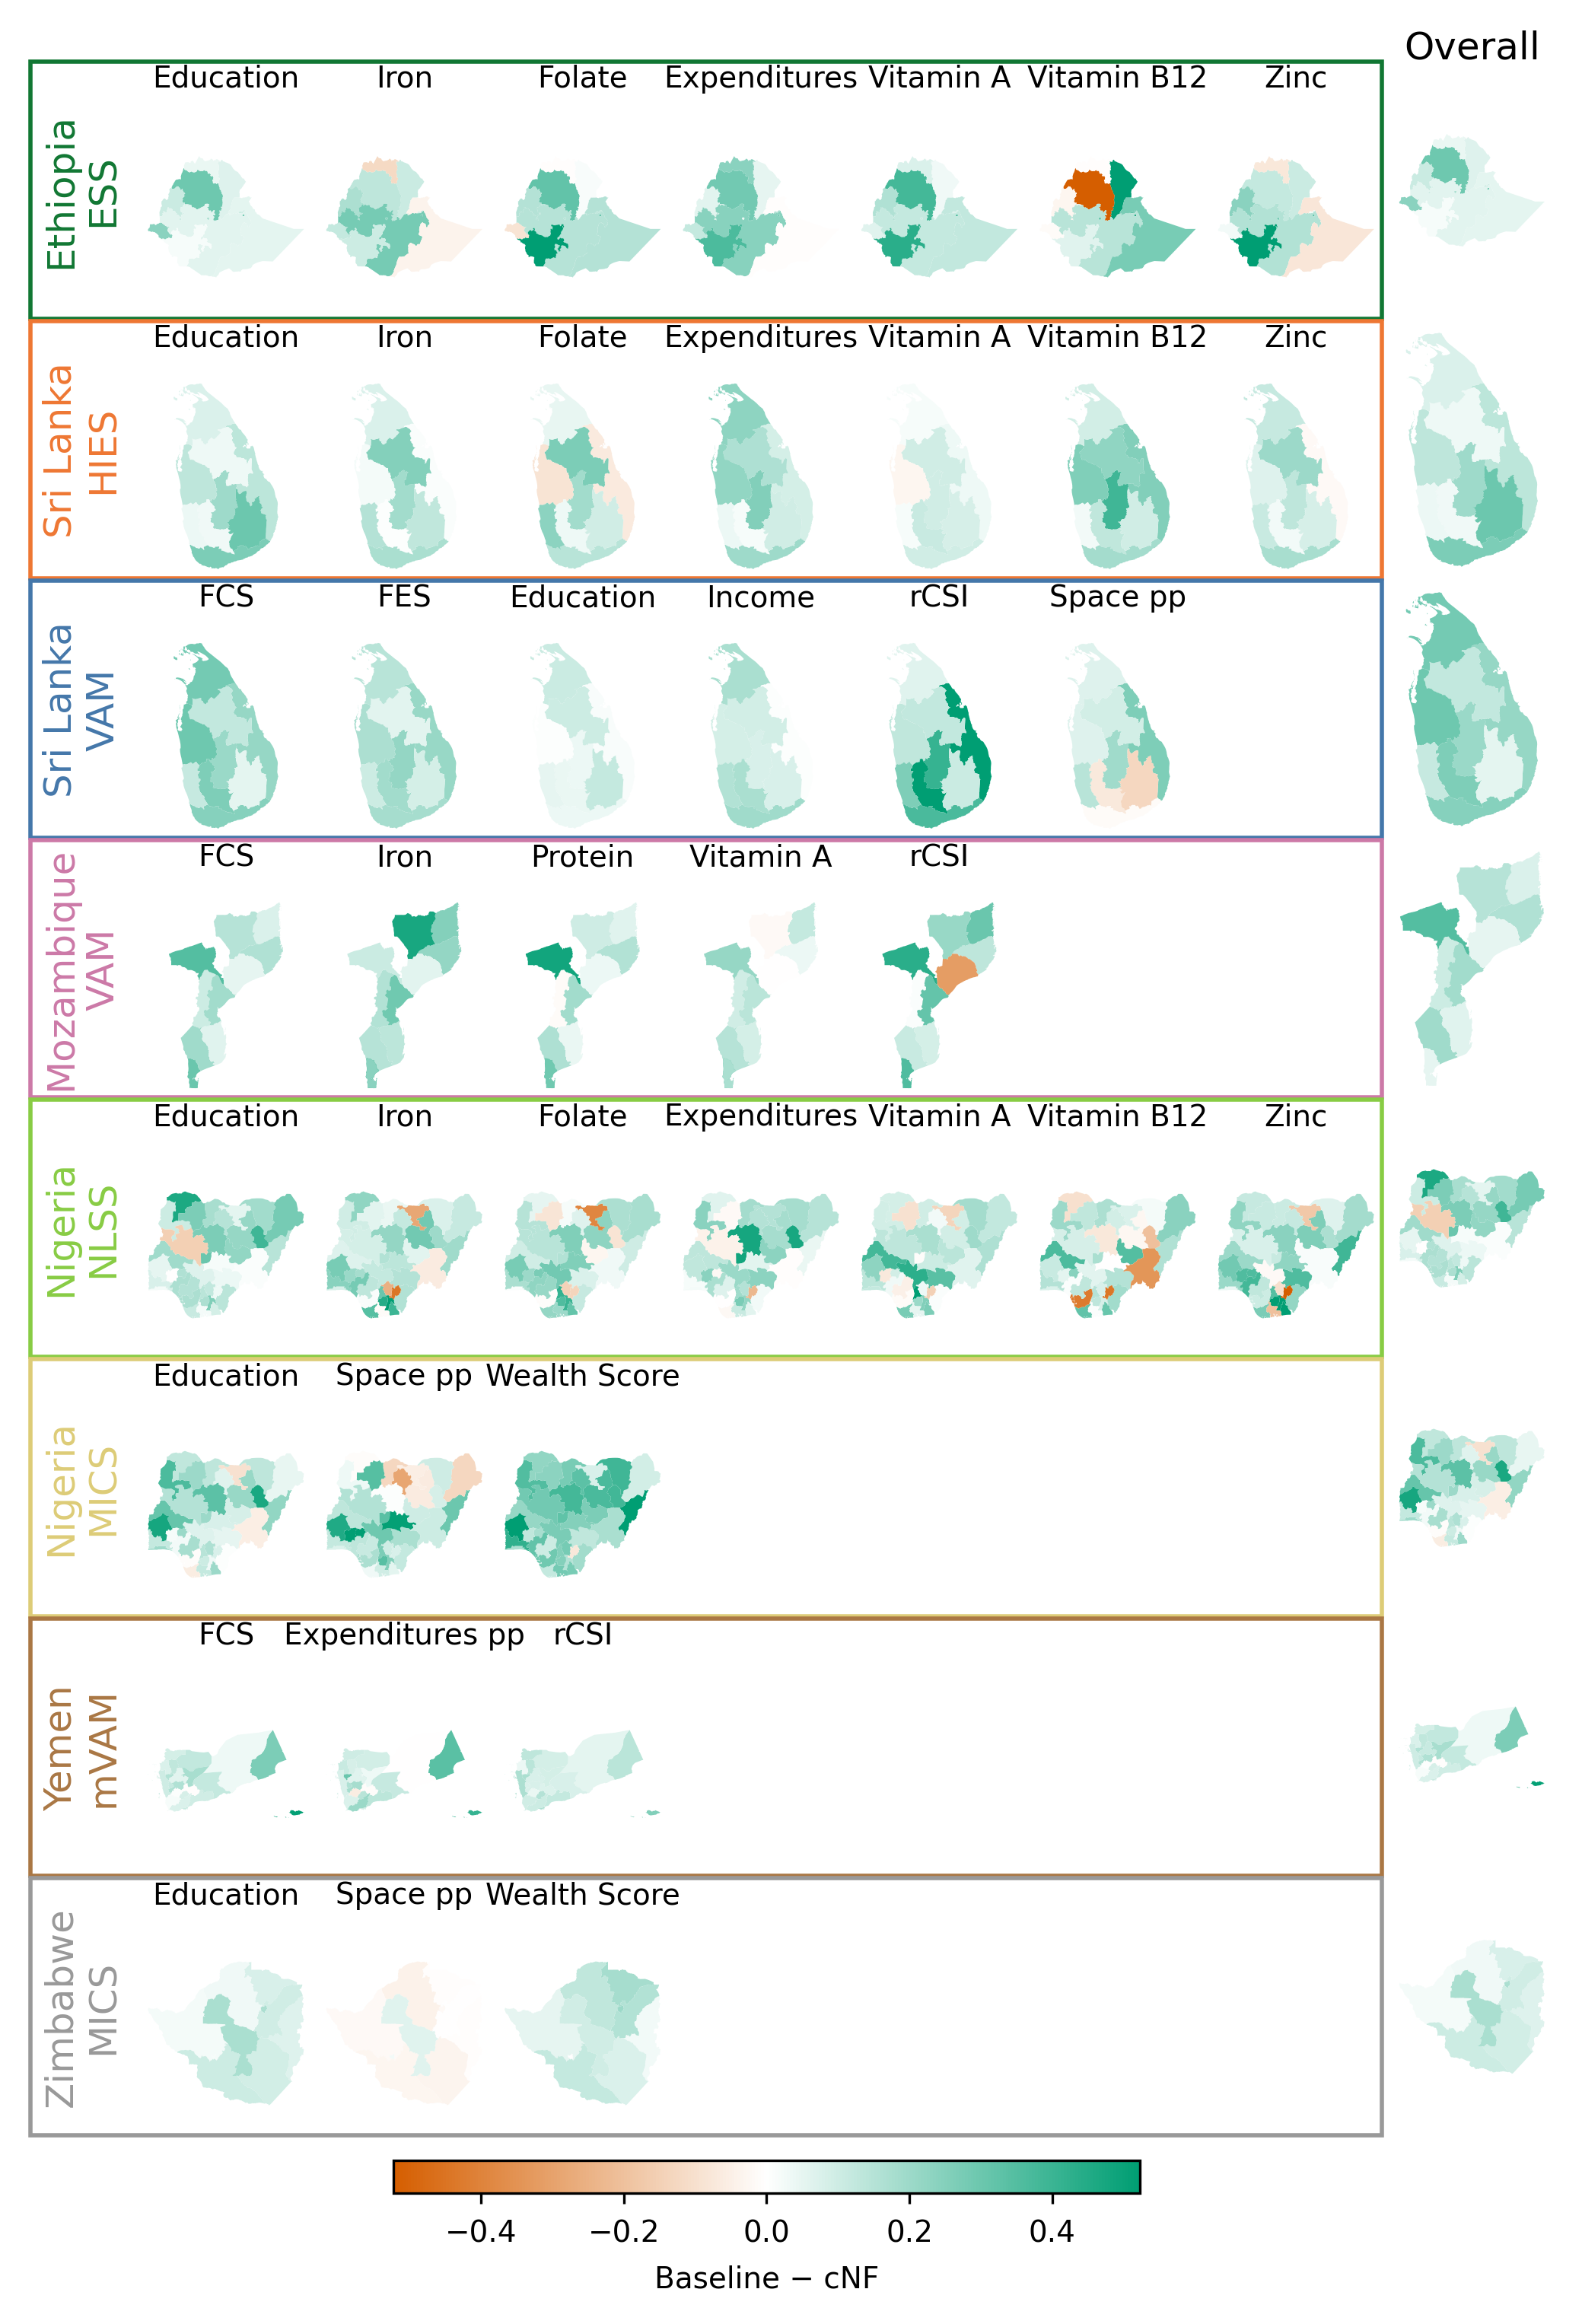

In [22]:
plot_improvement(gdf, "imp_emd_over", "Improvement in distributions refinement")


## Improvement with intrinsic variability

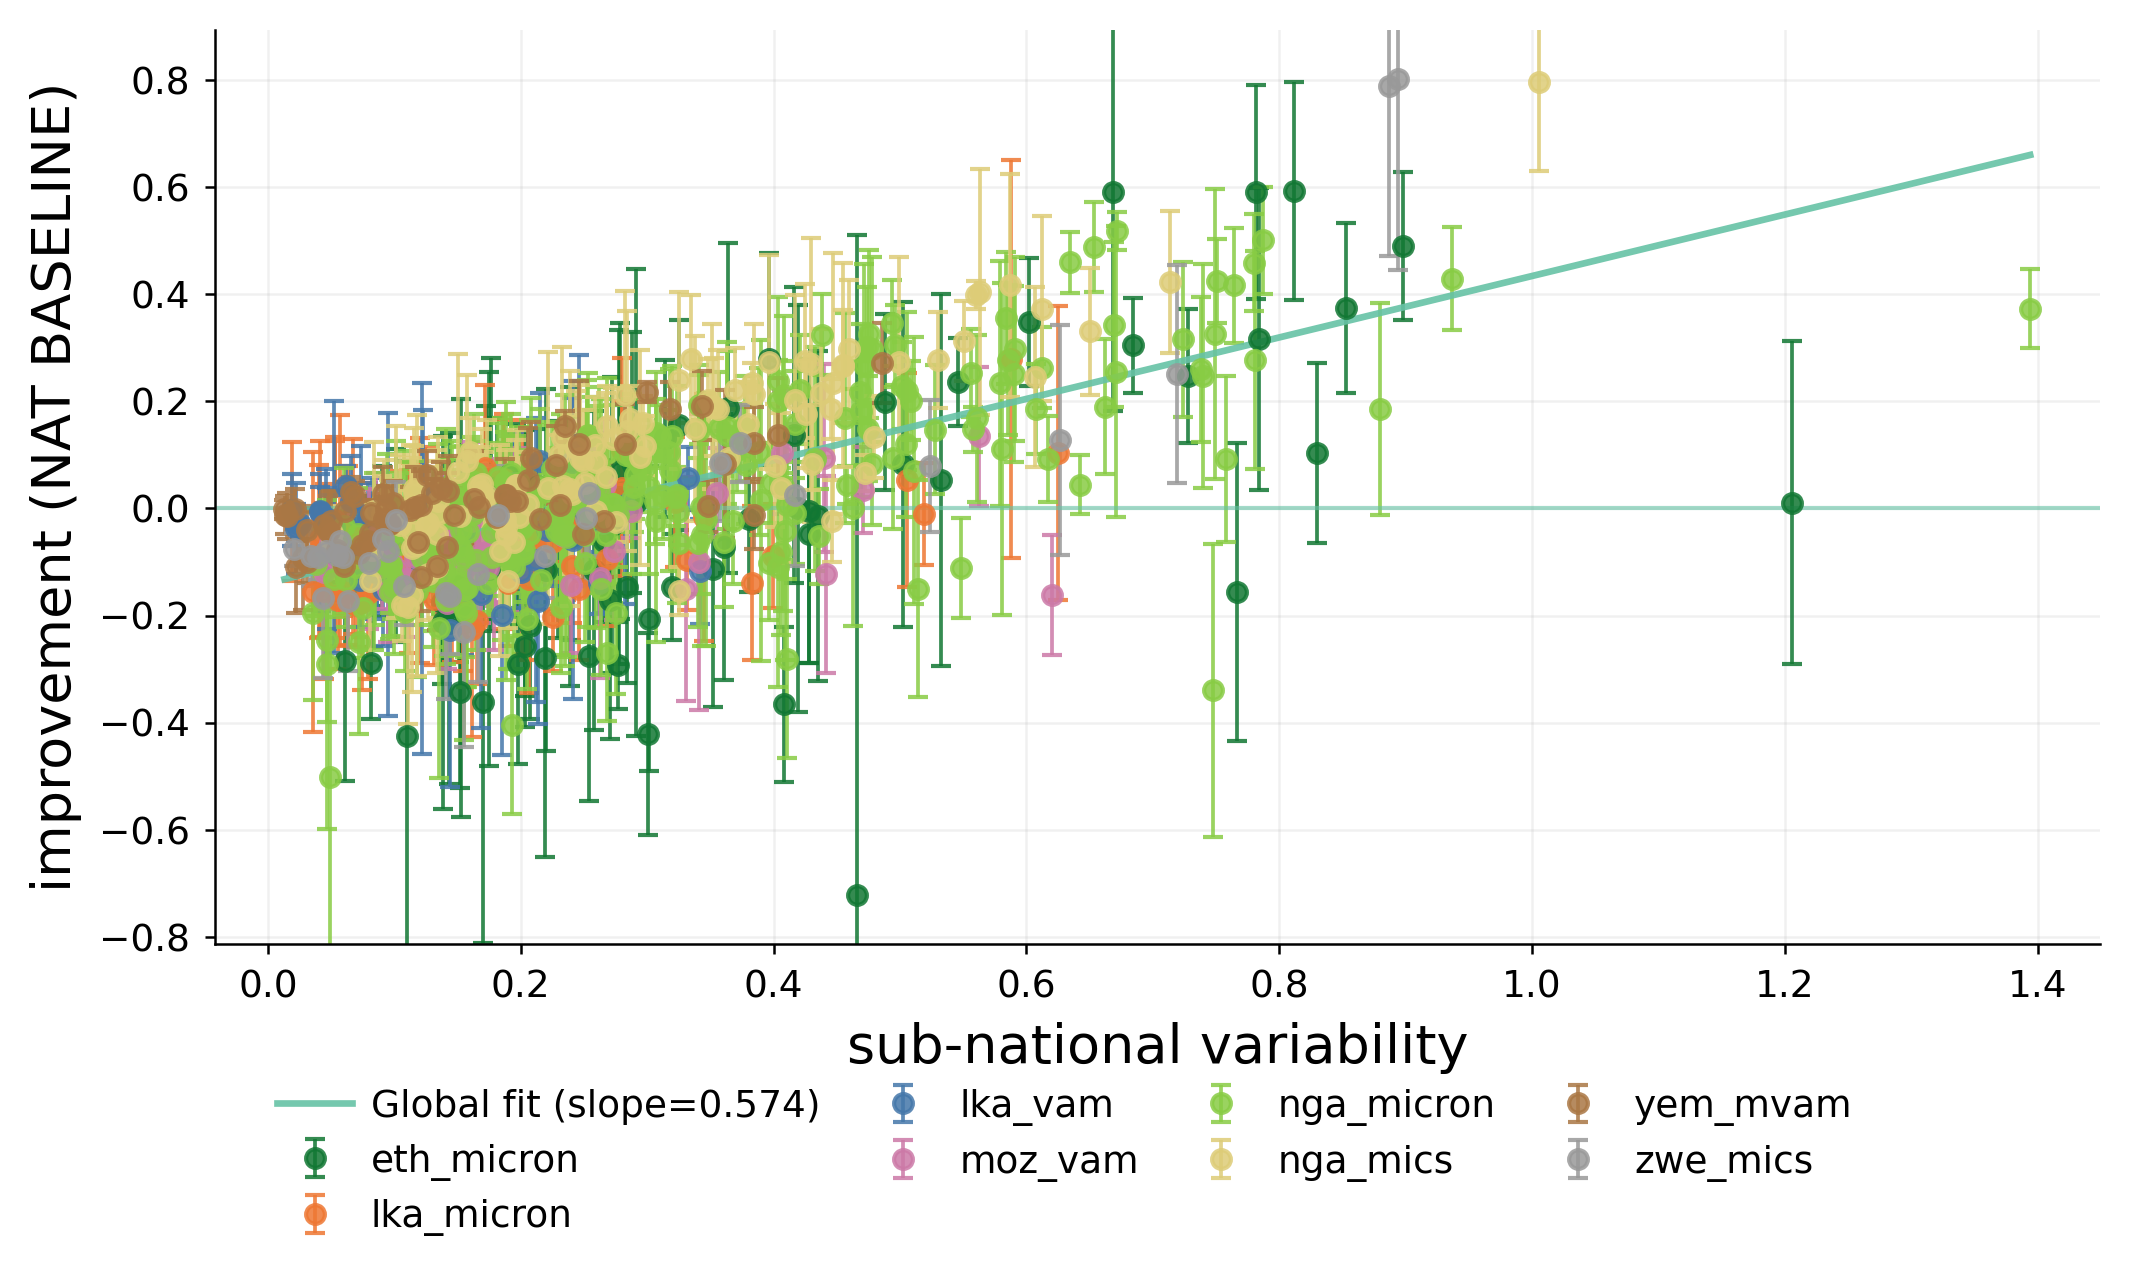

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- load ---
csv_path = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/metrics_all_experiments.csv"
df = pd.read_csv(csv_path)

# numeric
for c in ["variability_intrinsic", "emd_gen", "emd_nat"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# clean
df = (
    df.replace([np.inf, -np.inf], np.nan)
      .dropna(subset=["seed", "experiment_id", "adm1_code", "target",
                      "variability_intrinsic", "emd_gen", "emd_nat"])
      .copy()
)

# --- compute gain per seed first ---
df["emd_gain_vs_nat"] = df["emd_nat"] - df["emd_gen"]

# --- aggregate over seeds (per exp x adm1 x target) ---
grp_cols = ["experiment_id", "adm1_code", "target"]
m = (
    df.groupby(grp_cols, as_index=False)
      .agg(
          variability_intrinsic_mean=("variability_intrinsic", "mean"),
          variability_intrinsic_sd=("variability_intrinsic", "std"),
          emd_gain_mean=("emd_gain_vs_nat", "mean"),
          emd_gain_sd=("emd_gain_vs_nat", "std"),
          n_seeds=("seed", "nunique"),
      )
)

# replace NaN std (e.g., only 1 seed) with 0 for plotting
m["emd_gain_sd"] = m["emd_gain_sd"].fillna(0.0)

# ---- style ----
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

exp_ids = sorted(m["experiment_id"].unique())

# colors (keep your prior mapping if it exists)
if "exp_color_map" in globals():
    color_map = {e: exp_color_map.get(e, None) for e in exp_ids}
else:
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {e: cycle[i % len(cycle)] for i, e in enumerate(exp_ids)} if cycle else {e: None for e in exp_ids}

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300)

# --- scatter + error bars ---
for exp_id in exp_ids:
    sub = m[m["experiment_id"] == exp_id]
    ax.errorbar(
        sub["variability_intrinsic_mean"],
        sub["emd_gain_mean"],
        yerr=sub["emd_gain_sd"],
        fmt="o",
        ms=4.5,
        elinewidth=0.9,
        capsize=2.5,
        alpha=0.85,
        color=color_map.get(exp_id, None),
        label=exp_id
    )

ax.axhline(0, linewidth=1.0, alpha=0.6)
ax.set_xlabel("sub-national variability", fontsize=13)
ax.set_ylabel("improvement (NAT BASELINE)",fontsize=13)
ax.grid(True, alpha=0.18, linewidth=0.6)

# --- regression: global fit line ---
x = m["variability_intrinsic_mean"].to_numpy()
y = m["emd_gain_mean"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2:
    # y = a*x + b
    a, b = np.polyfit(x[mask], y[mask], deg=1)
    xx = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 200)
    yy = a * xx + b
    ax.plot(xx, yy, linewidth=1.6, alpha=0.9, label=f"Global fit (slope={a:.3g})")

# --- OPTIONAL: per-experiment fit lines (comment out if you don't want them) ---
# for exp_id in exp_ids:
#     sub = m[m["experiment_id"] == exp_id]
#     xs = sub["variability_intrinsic_mean"].to_numpy()
#     ys = sub["emd_gain_mean"].to_numpy()
#     mk = np.isfinite(xs) & np.isfinite(ys)
#     if mk.sum() >= 2:
#         a, b = np.polyfit(xs[mk], ys[mk], deg=1)
#         xx = np.linspace(np.nanmin(xs[mk]), np.nanmax(xs[mk]), 50)
#         ax.plot(xx, a*xx + b, linewidth=1.2, alpha=0.55, color=color_map.get(exp_id, None))

# limits with padding
if mask.any():
    xlo, xhi = np.nanmin(x[mask]), np.nanmax(x[mask])
    ylo, yhi = np.nanmin(y[mask]), np.nanmax(y[mask])
    xpad = 0.04 * (xhi - xlo) if xhi > xlo else 0.1
    ypad = 0.06 * (yhi - ylo) if yhi > ylo else 0.1
    ax.set_xlim(xlo - xpad, xhi + xpad)
    ax.set_ylim(ylo - ypad, yhi + ypad)

# legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(labels)),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5
)
fig.tight_layout(rect=[0, 0.10, 1, 1])

plt.show()

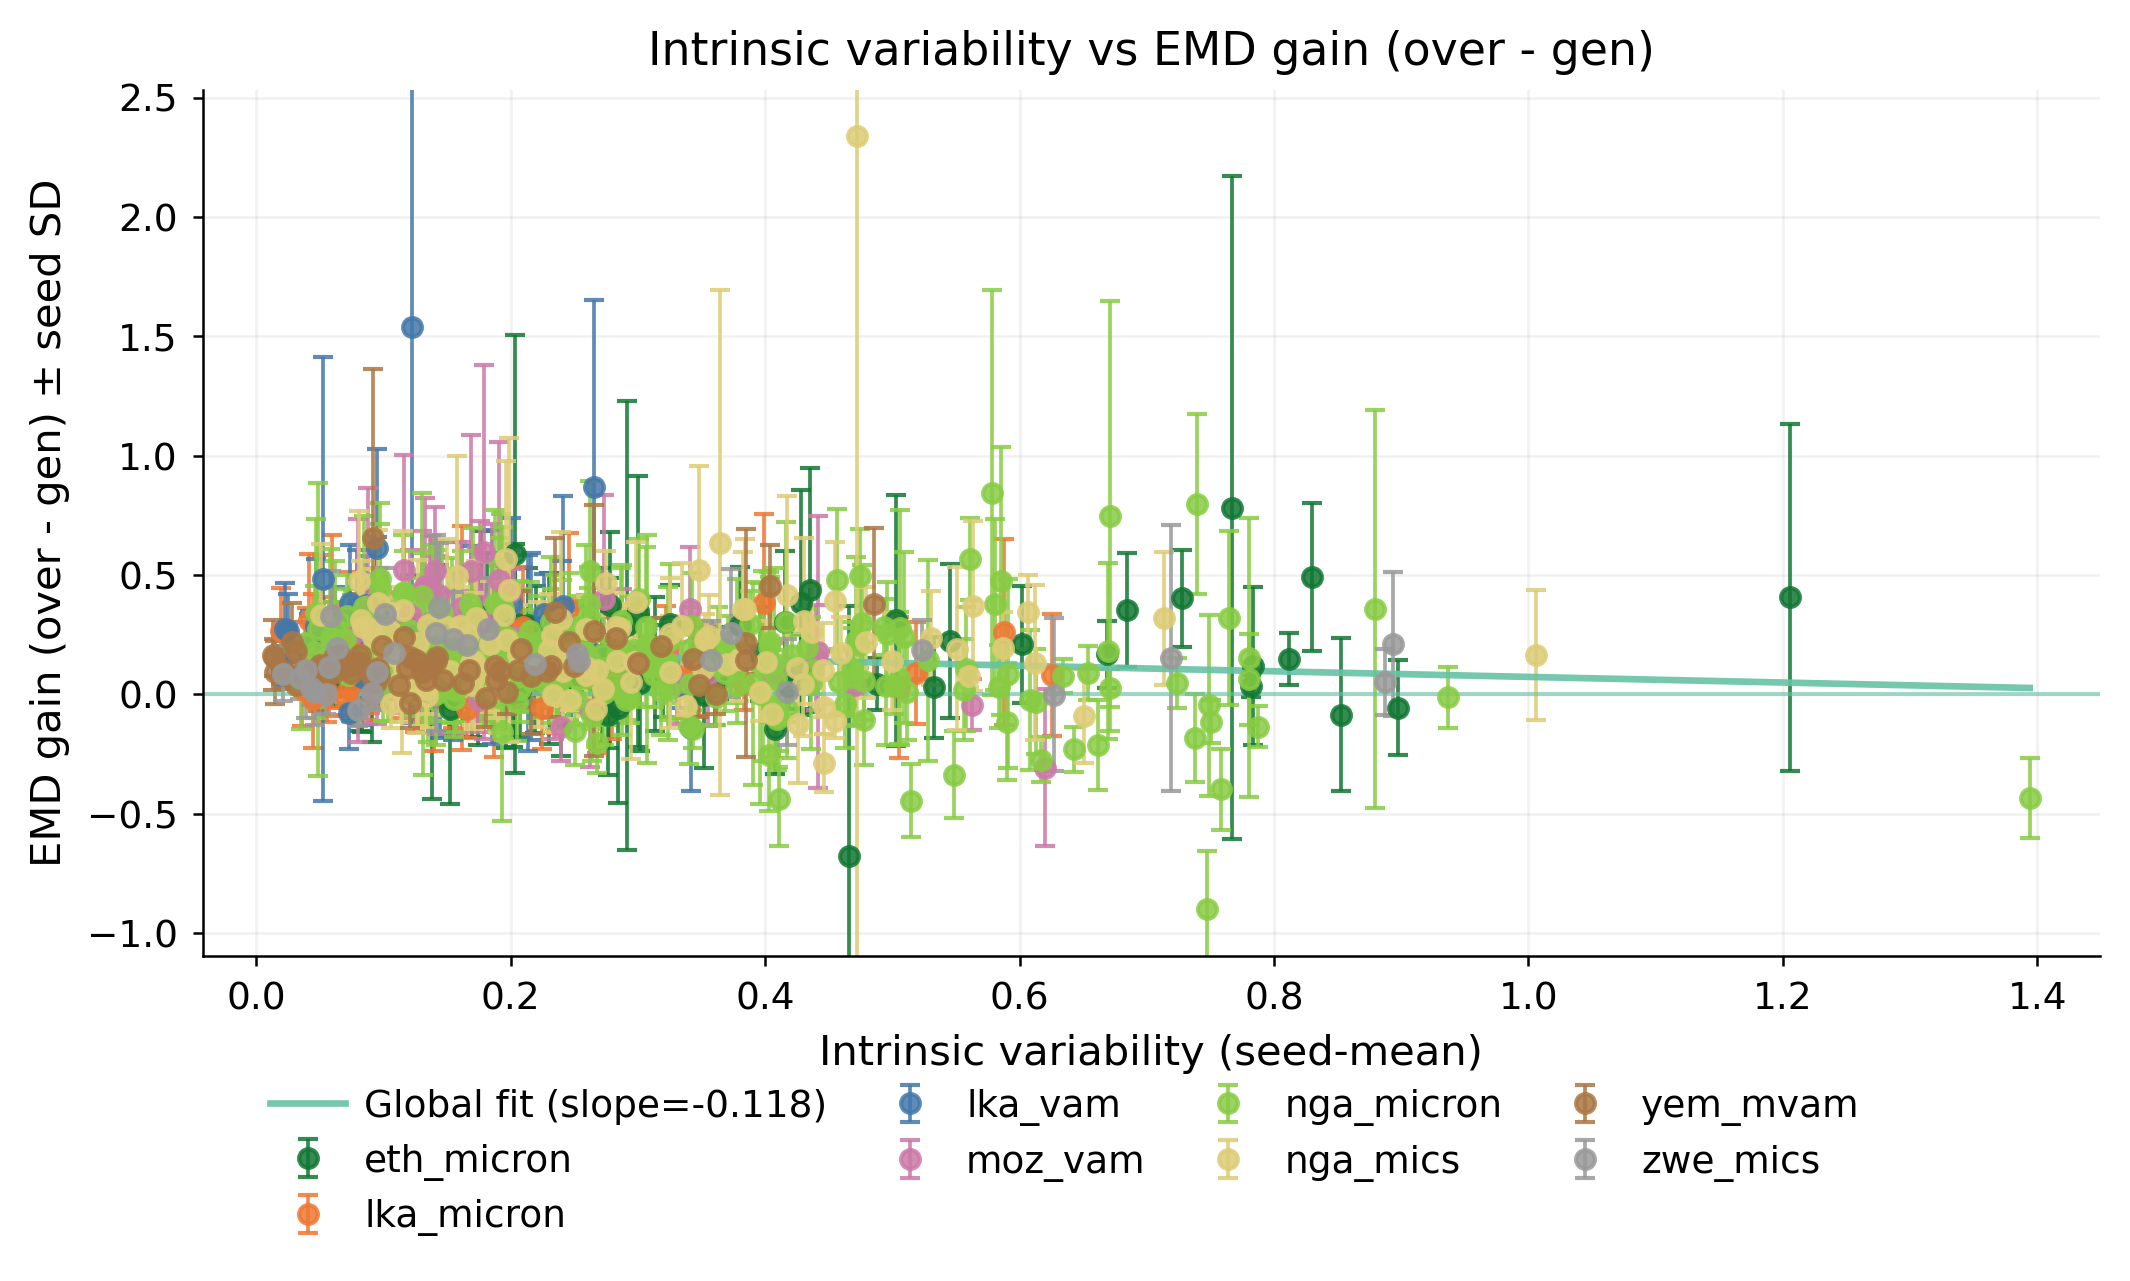

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/metrics_all_experiments.csv"
df = pd.read_csv(csv_path)

# numeric
for c in ["variability_intrinsic", "emd_gen", "emd_over"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# clean
df = (
    df.replace([np.inf, -np.inf], np.nan)
      .dropna(subset=["seed", "experiment_id", "adm1_code", "target",
                      "variability_intrinsic", "emd_gen", "emd_over"])
      .copy()
)

# --- compute gain per seed first (GEN vs OVER) ---
df["emd_gain_over_minus_gen"] = df["emd_over"] - df["emd_gen"]

# --- aggregate over seeds (per exp x adm1 x target) ---
grp_cols = ["experiment_id", "adm1_code", "target"]
m = (
    df.groupby(grp_cols, as_index=False)
      .agg(
          variability_intrinsic_mean=("variability_intrinsic", "mean"),
          variability_intrinsic_sd=("variability_intrinsic", "std"),
          emd_gain_mean=("emd_gain_over_minus_gen", "mean"),
          emd_gain_sd=("emd_gain_over_minus_gen", "std"),
          n_seeds=("seed", "nunique"),
      )
)

m["emd_gain_sd"] = m["emd_gain_sd"].fillna(0.0)

# ---- style ----
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

exp_ids = sorted(m["experiment_id"].unique())

# colors (reuse your prior mapping if it exists)
if "exp_color_map" in globals():
    color_map = {e: exp_color_map.get(e, None) for e in exp_ids}
else:
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {e: cycle[i % len(cycle)] for i, e in enumerate(exp_ids)} if cycle else {e: None for e in exp_ids}

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300)

# --- scatter + error bars ---
for exp_id in exp_ids:
    sub = m[m["experiment_id"] == exp_id]
    ax.errorbar(
        sub["variability_intrinsic_mean"],
        sub["emd_gain_mean"],
        yerr=sub["emd_gain_sd"],
        fmt="o",
        ms=4.5,
        elinewidth=0.9,
        capsize=2.5,
        alpha=0.85,
        color=color_map.get(exp_id, None),
        label=exp_id
    )

ax.axhline(0, linewidth=1.0, alpha=0.6)
ax.set_xlabel("Intrinsic variability (seed-mean)")
ax.set_ylabel("EMD gain (over - gen) ± seed SD")
ax.set_title("Intrinsic variability vs EMD gain (over - gen)")
ax.grid(True, alpha=0.18, linewidth=0.6)

# --- regression: global fit line ---
x = m["variability_intrinsic_mean"].to_numpy()
y = m["emd_gain_mean"].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2:
    a, b = np.polyfit(x[mask], y[mask], deg=1)
    xx = np.linspace(np.nanmin(x[mask]), np.nanmax(x[mask]), 200)
    yy = a * xx + b
    ax.plot(xx, yy, linewidth=1.6, alpha=0.9, label=f"Global fit (slope={a:.3g})")

# limits with padding
if mask.any():
    xlo, xhi = np.nanmin(x[mask]), np.nanmax(x[mask])
    ylo, yhi = np.nanmin(y[mask]), np.nanmax(y[mask])
    xpad = 0.04 * (xhi - xlo) if xhi > xlo else 0.1
    ypad = 0.06 * (yhi - ylo) if yhi > ylo else 0.1
    ax.set_xlim(xlo - xpad, xhi + xpad)
    ax.set_ylim(ylo - ypad, yhi + ypad)

# legend outside
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=min(4, len(labels)),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.5
)
fig.tight_layout(rect=[0, 0.10, 1, 1])

plt.show()

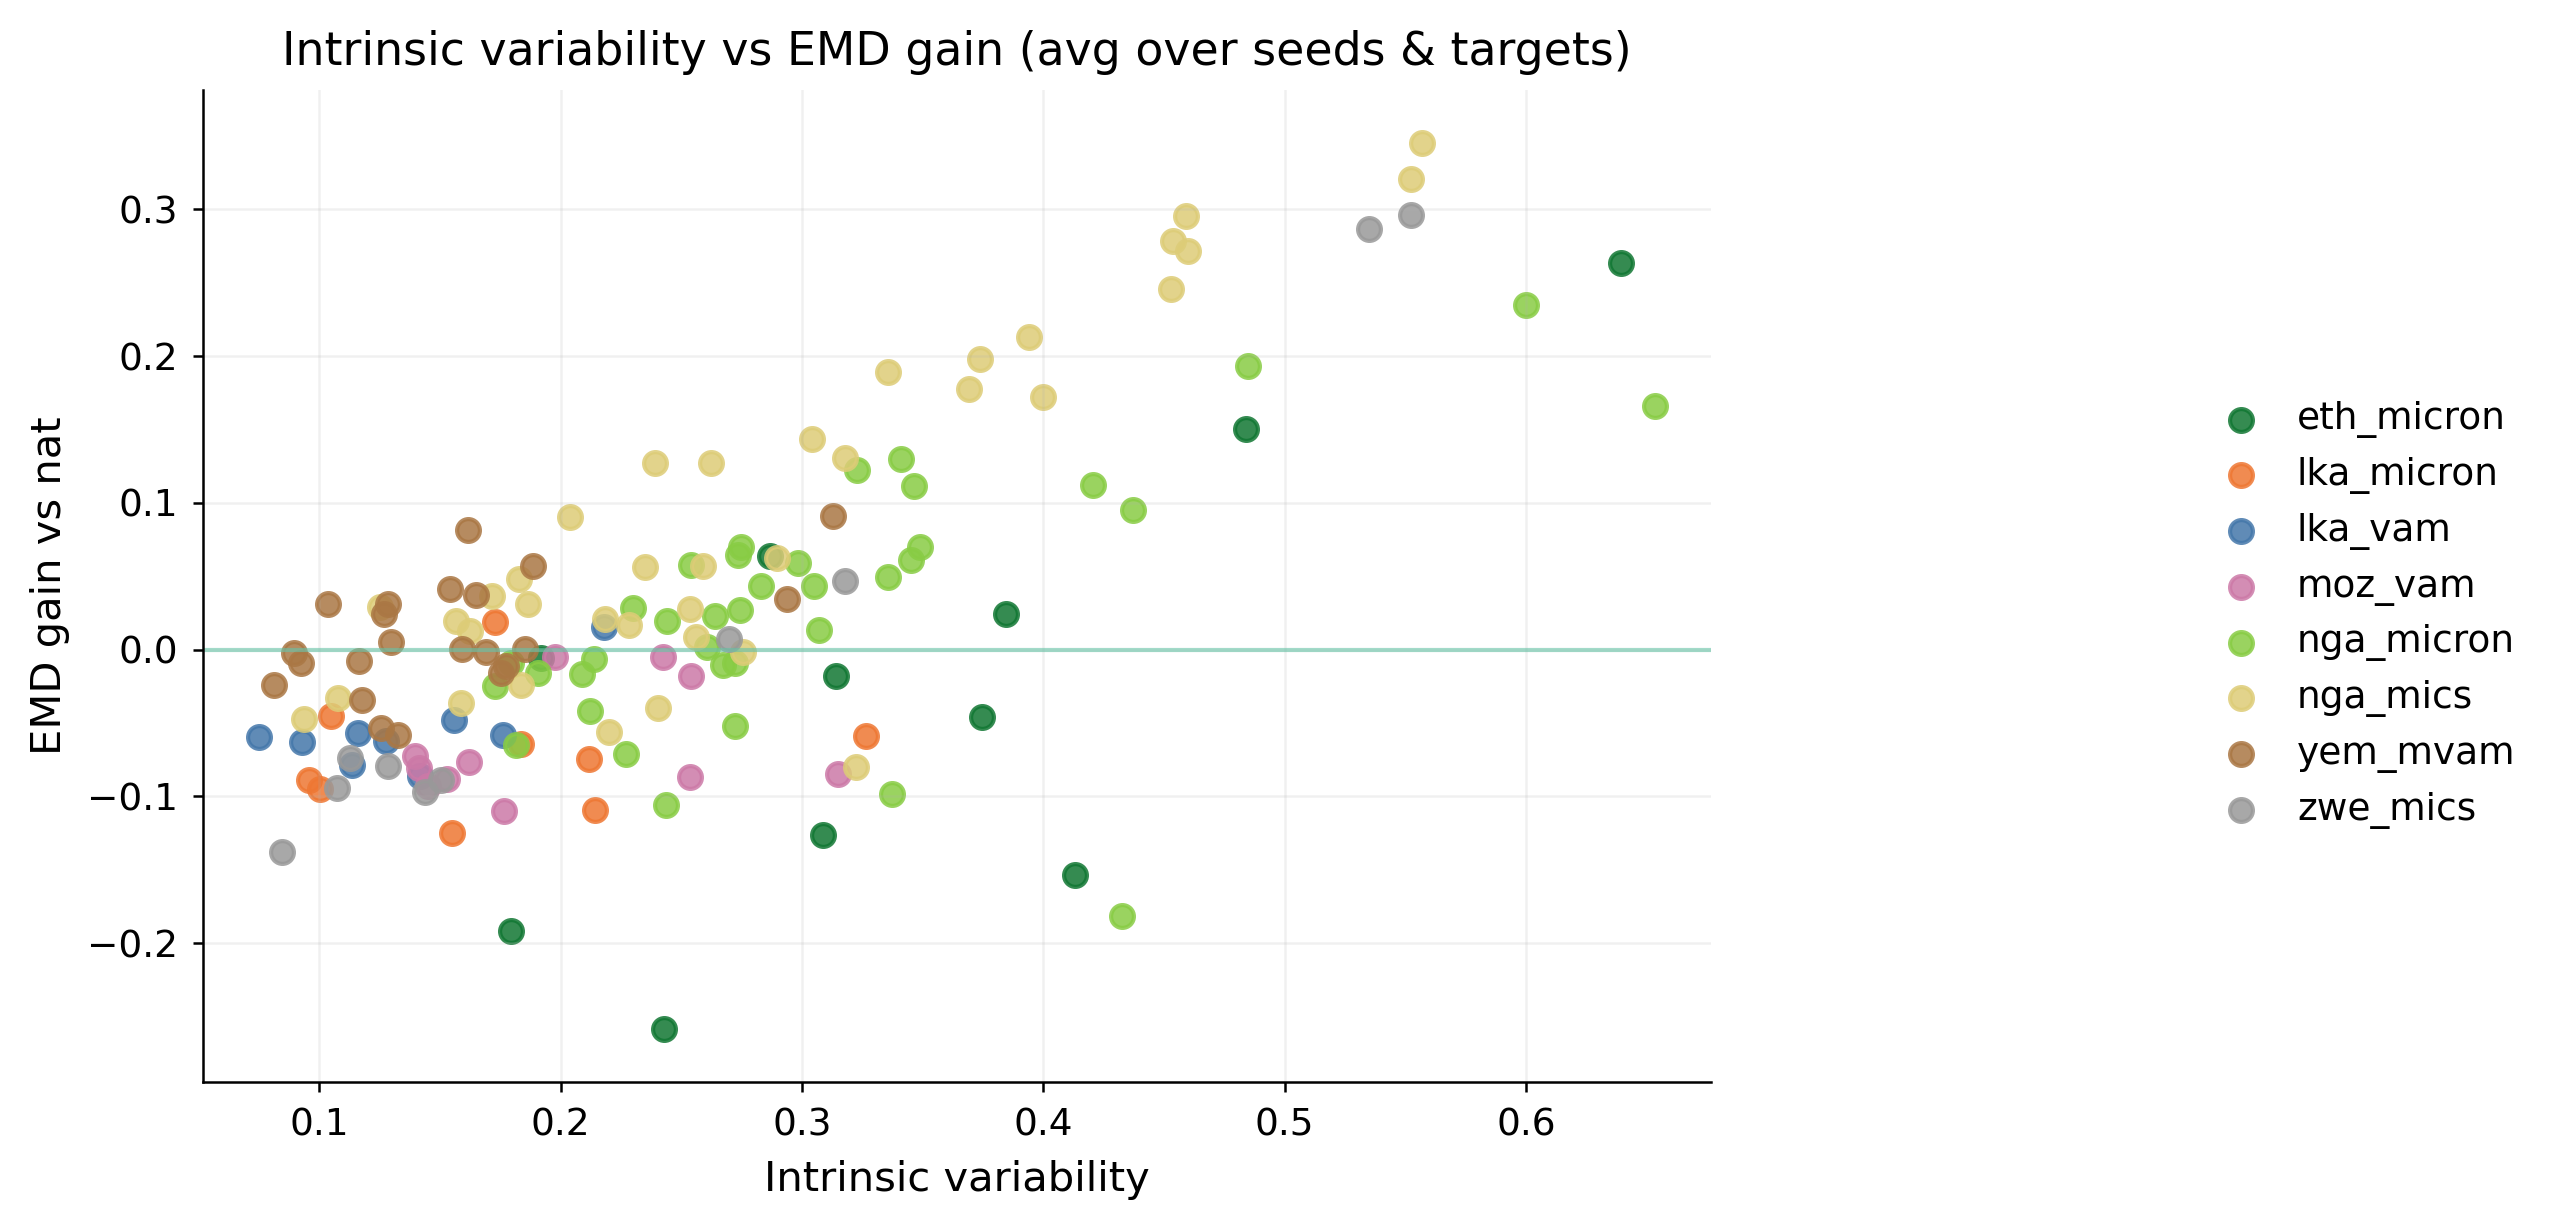

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/metrics_all_experiments.csv"
df = pd.read_csv(csv_path)

# numeric
for c in ["variability_intrinsic", "emd_gen", "emd_nat"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# clean
df = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["experiment_id", "adm1_code", "target", "variability_intrinsic", "emd_gen", "emd_nat"]
).copy()

# 1) average over seeds first: (experiment, adm1, target)
g1 = (
    df.groupby(["experiment_id", "adm1_code", "target"], as_index=False)
      .agg(
          variability_intrinsic=("variability_intrinsic", "mean"),
          emd_gen=("emd_gen", "mean"),
          emd_nat=("emd_nat", "mean"),
      )
)

# 2) then average over targets: (experiment, adm1)
g2 = (
    g1.groupby(["experiment_id", "adm1_code"], as_index=False)
      .agg(
          variability_intrinsic=("variability_intrinsic", "mean"),
          emd_gen=("emd_gen", "mean"),
          emd_nat=("emd_nat", "mean"),
      )
)

# 3) improvement vs nat AFTER averaging
g2["emd_gain_vs_nat"] = g2["emd_nat"] - g2["emd_gen"]

# ---- style ----
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

exp_ids = sorted(g2["experiment_id"].unique())

# same colors as before
if "exp_color_map" in globals():
    color_map = {e: exp_color_map.get(e, None) for e in exp_ids}
else:
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    color_map = {e: cycle[i % len(cycle)] for i, e in enumerate(exp_ids)} if cycle else {e: None for e in exp_ids}

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=300)

for exp_id in exp_ids:
    sub = g2[g2["experiment_id"] == exp_id]
    ax.scatter(
        sub["variability_intrinsic"],
        sub["emd_gain_vs_nat"],
        s=30,
        alpha=0.85,
        color=color_map.get(exp_id, None),
        label=exp_id
    )

ax.axhline(0, linewidth=1.0, alpha=0.6)

ax.set_xlabel("Intrinsic variability")
ax.set_ylabel("EMD gain vs nat")
ax.set_title("Intrinsic variability vs EMD gain (avg over seeds & targets)")

ax.grid(True, alpha=0.18, linewidth=0.6)

# padded limits
x = g2["variability_intrinsic"].to_numpy()
y = g2["emd_gain_vs_nat"].to_numpy()
xm = np.isfinite(x); ym = np.isfinite(y)
if xm.any():
    xlo, xhi = np.nanmin(x[xm]), np.nanmax(x[xm])
    xpad = 0.04 * (xhi - xlo) if xhi > xlo else 0.1
    ax.set_xlim(xlo - xpad, xhi + xpad)
if ym.any():
    ylo, yhi = np.nanmin(y[ym]), np.nanmax(y[ym])
    ypad = 0.06 * (yhi - ylo) if yhi > ylo else 0.1
    ax.set_ylim(ylo - ypad, yhi + ypad)

# legend outside (vertical)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),   # to the right, vertically centered
    ncol=1,                       # <- vertical legend
    frameon=False,
    handletextpad=0.5,
    borderaxespad=0.0
)

# make room on the right for the legend
fig.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()